# Mental Health Survey Data Analysis - Complete EDA Project
## Comprehensive Exploratory Data Analysis using Python (Matplotlib & Seaborn)

This notebook provides a complete end-to-end data analysis pipeline for the Mental Health Survey Dataset, including:
- Data loading and inspection
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Statistical analysis
- Advanced visualizations using Matplotlib and Seaborn

**Dataset**: Mental_Health-Survey.xlsx

**Dataset consists of 3 relational sheets:**
| Sheet | Rows | Columns | Description |
|---|---|---|---|
| `Respondent` | 1,565 | 5 | Demographics — Age, Gender, State, Role |
| `Lifestyle_Habits` | 1,565 | 11 | Sleep, activity, screen time, coping habits |
| `Mental_Health_Assessment` | 1,565 | 19 | PHQ/GAD-style scores, therapist consultation, MH outcome |

**Objectives:**
- Understand demographic distribution of respondents
- Identify lifestyle patterns and their link to mental health
- Visualise key indicators: stress, burnout, anxiety, depression
- Explore correlations between lifestyle choices and mental health outcomes

---
## 1. IMPORT LIBRARIES
Import all required libraries for data analysis, visualization, and statistical analysis

In [38]:
# Import core libraries
import numpy as np                          # Numerical computations
import pandas as pd                         # Data manipulation and analysis
import matplotlib.pyplot as plt             # Visualization library
import seaborn as sns                       # Statistical data visualization
from scipy import stats                     # Statistical tests and functions
from scipy.stats import zscore, iqr         # Outlier detection methods
import warnings                             # Warning suppression
import os                                   # Operating system functions

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')      # Set plot style
sns.set_palette("husl")                     # Set color palette
plt.rcParams['figure.figsize'] = (12, 6)    # Default figure size
plt.rcParams['font.size'] = 10              # Default font size


print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

✓ All libraries imported successfully!
NumPy version: 2.4.4
Pandas version: 3.0.2
Matplotlib version: 3.10.9
Seaborn version: 0.13.2


---
## 2. CREATE AND LOAD DATASET
Load the Mental Health Survey dataset from the xlsx file with proper error handling

In [39]:
# Define dataset filename - User can modify this
DATASET_FILENAME = "Mental_Health_Survey_.xlsx"

# Get current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Build full file path
file_path = os.path.join(current_dir, DATASET_FILENAME)

# Load dataset with error handling
try:
    df = pd.read_excel(file_path)
    print(f"\n ✓ Dataset loaded successfully!")
    print(f"File path: {file_path}")
    
except FileNotFoundError:
    print(f"✗ Error: File '{DATASET_FILENAME}' not found in {current_dir}")
    print("Please ensure the XLSX file exists in the current directory.")
except Exception as e:
    print(f"✗ Error loading file: {str(e)}")

# Display available files in directory
print("\n📁 Files in current directory:")
files = [f for f in os.listdir(current_dir) if f.endswith('.xlsx')]
for file in files:
    print(f"   - {file}")

# Display available sheets in the Excel file
xl = pd.ExcelFile(DATASET_FILENAME)
print('\n 📄 Sheets found:', xl.sheet_names)

# ── Load each sheet ───────────────────────────────────────────────────────
df_resp = pd.read_excel(xl, sheet_name='Respondent')
df_life = pd.read_excel(xl, sheet_name='Lifestyle_Habits')
df_mh   = pd.read_excel(xl, sheet_name='Mental_Health_Assessment')

print(f'\n   Respondent sheet          : {df_resp.shape}')
print(f'   Lifestyle_Habits sheet     : {df_life.shape}')
print(f'   Mental_Health_Assessment   : {df_mh.shape}')

# ── Merge all three into one master DataFrame ─────────────────────────────
df = (df_resp
      .merge(df_life, on='Respondent_ID')
      .merge(df_mh,   on='Respondent_ID'))

print(f'\n✅ Merged DataFrame shape : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)')


Current working directory: c:\Users\agent\Desktop\apponix\Project

 ✓ Dataset loaded successfully!
File path: c:\Users\agent\Desktop\apponix\Project\Mental_Health_Survey_.xlsx

📁 Files in current directory:
   - Mental_Health-Survey.xlsx
   - Mental_Health_Survey_.xlsx

 📄 Sheets found: ['Respondent', 'Lifestyle_Habits', 'Mental_Health_Assessment']

   Respondent sheet          : (1565, 5)
   Lifestyle_Habits sheet     : (1565, 11)
   Mental_Health_Assessment   : (1565, 19)

✅ Merged DataFrame shape : (1565, 33)  (1565 rows × 33 columns)


---
## 3. BASIC DATA INSPECTION And DATA PREPROCESSING
Perform initial exploration of the dataset using various inspection functions

In [40]:
# 1. Display first few rows
print("="*80)
print("1. FIRST 5 ROWS (head)")
print("="*80)
df.head()

1. FIRST 5 ROWS (head)


,Respondent_ID,Age,Gender,State,Role,Lifestyle_ID,Work_Study_Hrs,Sleep_Hrs,Physical_Activity_Days,Screen_Time,...,Stress_Level,Burnout,Work_Pressure,WL_Balance,Life_Control,Family_Support,Coping_Mechanism,Therapist_Consult,Social_Support,MH_Affected
0,1,29,Female,Karnataka,Employed (full-time or part-time),1,More than 8 hours,5-6 hours,1-2 days,6+ hrs,...,4,4,4,3,3,4,"Entertainment (music, movies, gaming)",No,Yes,No
1,2,26,Female,Chhattisgarh,Student,2,4-6 hours,6-7 hours,0 days,4-6 hrs,...,2,2,1,4,4,5,"Entertainment (music, movies, gaming)",No,Yes,No
2,3,23,Male,Chhattisgarh,Student,3,4-6 hours,7 or more hours,1-2 days,2-4 hrs,...,3,2,2,3,2,5,Not Specified,No,No,No
3,4,22,Female,Chhattisgarh,Student,4,Less than 4 hours,7 or more hours,3-4 days,4-6 hrs,...,2,1,1,5,5,4,Talking to friends/family,No,Yes,No
4,5,22,Female,Andhra Pradesh,Student,5,6-8 hours,6-7 hours,3-4 days,2-4 hrs,...,1,1,3,5,5,5,Talking to friends/family,No,Yes,No


In [41]:
# 2. Display last few rows
print("\n" + "="*80)
print("2. LAST 5 ROWS (tail)")
print("="*80)
df.tail()


2. LAST 5 ROWS (tail)


,Respondent_ID,Age,Gender,State,Role,Lifestyle_ID,Work_Study_Hrs,Sleep_Hrs,Physical_Activity_Days,Screen_Time,...,Stress_Level,Burnout,Work_Pressure,WL_Balance,Life_Control,Family_Support,Coping_Mechanism,Therapist_Consult,Social_Support,MH_Affected
1560,1561,33,Male,Maharashtra,Employed (full-time or part-time),1561,More than 8 hours,6-7 hours,3-4 days,6+ hrs,...,2,3,2,3,3,2,"Entertainment (music, movies, gaming)",No,Yes,No
1561,1562,35,Male,Andhra Pradesh,Employed (full-time or part-time),1562,More than 8 hours,6-7 hours,3-4 days,6+ hrs,...,3,4,2,3,2,5,"Entertainment (music, movies, gaming)",No,No,Yes
1562,1563,22,Male,Uttar Pradesh,Student,1563,4-6 hours,Less than 5 hours,5+ days,4-6 hrs,...,2,4,4,2,3,4,"Entertainment (music, movies, gaming)",Yes,Yes,No
1563,1564,27,Female,Himachal Pradesh,Student,1564,6-8 hours,5-6 hours,0 days,2-4 hrs,...,3,5,3,4,3,4,Talking to friends/family,No,Yes,No
1564,1565,44,Female,Madhya Pradesh,Employed (full-time or part-time),1565,6-8 hours,6-7 hours,1-2 days,4-6 hrs,...,2,3,3,2,1,1,Talking to friends/family,No,Yes,No


In [42]:
# 3. Display random sample
print("\n" + "="*80)
print("3. RANDOM 5 ROWS (sample)")
print("="*80)
df.sample(5)


3. RANDOM 5 ROWS (sample)


,Respondent_ID,Age,Gender,State,Role,Lifestyle_ID,Work_Study_Hrs,Sleep_Hrs,Physical_Activity_Days,Screen_Time,...,Stress_Level,Burnout,Work_Pressure,WL_Balance,Life_Control,Family_Support,Coping_Mechanism,Therapist_Consult,Social_Support,MH_Affected
29,30,60,Male,Karnataka,Unemployed,30,More than 8 hours,6-7 hours,5+ days,6+ hrs,...,1,1,1,5,5,5,Not Specified,No,Yes,No
546,547,27,Male,Haryana,Employed (full-time or part-time),547,4-6 hours,7 or more hours,1-2 days,Less than 2 hrs,...,3,1,1,5,3,5,Substance use,No,No,No
1193,1194,21,Male,Maharashtra,Student,1194,More than 8 hours,7 or more hours,1-2 days,4-6 hrs,...,3,3,3,4,3,4,Talking to friends/family,No,No,No
1278,1279,30,Female,Andhra Pradesh,Employed (full-time or part-time),1279,More than 8 hours,6-7 hours,1-2 days,4-6 hrs,...,3,2,2,1,4,4,Exercise,No,Yes,No
1255,1256,21,Female,Delhi,Student,1256,Less than 4 hours,6-7 hours,1-2 days,4-6 hrs,...,3,2,2,5,3,4,Not Specified,No,Yes,No


In [43]:
# 4. Dataset shape
print("\n" + "="*80)
print("4. DATASET SHAPE")
print("="*80)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


4. DATASET SHAPE
Number of rows: 1565
Number of columns: 33


In [44]:
# 5. Column names
print("\n" + "="*80)
print("5. COLUMN NAMES")
print("="*80)
print(df.columns.tolist())


5. COLUMN NAMES
['Respondent_ID', 'Age', 'Gender', 'State', 'Role', 'Lifestyle_ID', 'Work_Study_Hrs', 'Sleep_Hrs', 'Physical_Activity_Days', 'Screen_Time', 'Outings_Freq', 'Sleep_Quality', 'SocialMedia_Mood', 'Regular_Breaks', 'Has_Coping_Strategy', 'Assessment_ID', 'Low_Interest', 'Depressed', 'Sleep_Trouble', 'Low_Energy', 'Poor_Concentration', 'Anxiety', 'Emotional_Drain', 'Stress_Level', 'Burnout', 'Work_Pressure', 'WL_Balance', 'Life_Control', 'Family_Support', 'Coping_Mechanism', 'Therapist_Consult', 'Social_Support', 'MH_Affected']


In [45]:
# 6. Data types
print("\n" + "="*80)
print("6. DATA TYPES")
print("="*80)
print(df.dtypes)


6. DATA TYPES
Respondent_ID             int64
Age                       int64
Gender                      str
State                       str
Role                        str
Lifestyle_ID              int64
Work_Study_Hrs              str
Sleep_Hrs                   str
Physical_Activity_Days      str
Screen_Time                 str
Outings_Freq                str
Sleep_Quality             int64
SocialMedia_Mood          int64
Regular_Breaks              str
Has_Coping_Strategy         str
Assessment_ID             int64
Low_Interest              int64
Depressed                 int64
Sleep_Trouble             int64
Low_Energy                int64
Poor_Concentration        int64
Anxiety                   int64
Emotional_Drain           int64
Stress_Level              int64
Burnout                   int64
Work_Pressure             int64
WL_Balance                int64
Life_Control              int64
Family_Support            int64
Coping_Mechanism            str
Therapist_Consult        

In [46]:
# 7. Info about dataset
print("\n" + "="*80)
print("7. DATASET INFO")
print("="*80)
df.info()


7. DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Respondent_ID           1565 non-null   int64
 1   Age                     1565 non-null   int64
 2   Gender                  1565 non-null   str  
 3   State                   1565 non-null   str  
 4   Role                    1565 non-null   str  
 5   Lifestyle_ID            1565 non-null   int64
 6   Work_Study_Hrs          1565 non-null   str  
 7   Sleep_Hrs               1565 non-null   str  
 8   Physical_Activity_Days  1565 non-null   str  
 9   Screen_Time             1565 non-null   str  
 10  Outings_Freq            1565 non-null   str  
 11  Sleep_Quality           1565 non-null   int64
 12  SocialMedia_Mood        1565 non-null   int64
 13  Regular_Breaks          1565 non-null   str  
 14  Has_Coping_Strategy     1565 non-null   str  
 15  Assessment_ID  

In [47]:
# 8. Statistical description
print("\n" + "="*80)
print("8. STATISTICAL DESCRIPTION")
print("="*80)
df.describe().T.round(2)


8. STATISTICAL DESCRIPTION


,count,mean,std,min,25%,50%,75%,max
Respondent_ID,1565.0,783.00,451.92,1.0,392.0,783.0,1174.0,1565.0
Age,1565.0,27.79,8.58,16.0,22.0,25.0,33.0,60.0
Lifestyle_ID,1565.0,783.00,451.92,1.0,392.0,783.0,1174.0,1565.0
Sleep_Quality,1565.0,2.98,1.16,1.0,2.0,3.0,4.0,5.0
SocialMedia_Mood,1565.0,2.93,1.40,1.0,2.0,3.0,4.0,5.0
Assessment_ID,1565.0,783.00,451.92,1.0,392.0,783.0,1174.0,1565.0
Low_Interest,1565.0,2.83,1.12,1.0,2.0,3.0,4.0,5.0
Depressed,1565.0,2.66,1.11,1.0,2.0,3.0,3.0,5.0
Sleep_Trouble,1565.0,2.50,1.07,1.0,2.0,2.0,3.0,5.0
Low_Energy,1565.0,2.64,1.08,1.0,2.0,3.0,3.0,5.0


In [48]:
# 9. Index information
print("\n" + "="*80)
print("9. INDEX INFORMATION")
print("="*80)
print(f"Index name: {df.index.name}")
print(f"Index length: {len(df.index)}")
print(f"Index range: {df.index.min()} to {df.index.max()}")


9. INDEX INFORMATION
Index name: None
Index length: 1565
Index range: 0 to 1564


In [ ]:
# 10. Unique and Null values for each column
print("\n" + "="*80)
print("10. UNIQUE VALUES & NULL COUNT PER COLUMN")
print("="*80)
null_unique = pd.DataFrame({
    'Null_Count': df.isnull().sum(),
    'Null_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique_Values': df.nunique(),
    'Data_Type': df.dtypes
}).sort_values('Null_Count', ascending=False)

print(null_unique)
print(f'\n✅ Total nulls  : {df.isnull().sum().sum()}')
print(f'   Dataset is {"COMPLETE — no missing values." if df.isnull().sum().sum()==0 else "contains missing values."}')



10. UNIQUE VALUES & NULL COUNT PER COLUMN
                        Null_Count  Null_Percentage  Unique_Values Data_Type
Respondent_ID                    0              0.0           1565     int64
Age                              0              0.0             37     int64
Gender                           0              0.0              2       str
State                            0              0.0             20       str
Role                             0              0.0              3       str
Lifestyle_ID                     0              0.0           1565     int64
Work_Study_Hrs                   0              0.0              4       str
Sleep_Hrs                        0              0.0              4       str
Physical_Activity_Days           0              0.0              4       str
Screen_Time                      0              0.0              4       str
Outings_Freq                     0              0.0              4       str
Sleep_Quality                    

In [ ]:
# 11. Value counts for categorical columns
print("\n" + "="*80)
print("11. VALUE COUNTS FOR KEY CATEGORICAL COLUMNS")
print("="*80)

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols[:5]:  # Show first 5 categorical columns
    print(f"\n{col}:")
    print(df[col].value_counts())


11. VALUE COUNTS FOR KEY CATEGORICAL COLUMNS

Gender:
Gender
Male      815
Female    750
Name: count, dtype: int64

State:
State
Andhra Pradesh      206
Karnataka           183
Telangana           160
Tamil Nadu          145
Uttar Pradesh       121
Chhattisgarh        104
Maharashtra          90
Kerala               81
Delhi                62
Rajasthan            59
Himachal Pradesh     58
Madhya Pradesh       49
Gujarat              41
Punjab               34
Haryana              34
Jharkhand            33
West Bengal          30
Bihar                26
Assam                25
Odisha               24
Name: count, dtype: int64

Role:
Role
Student                              769
Employed (full-time or part-time)    601
Unemployed                           195
Name: count, dtype: int64

Work_Study_Hrs:
Work_Study_Hrs
6-8 hours            612
4-6 hours            464
More than 8 hours    320
Less than 4 hours    169
Name: count, dtype: int64

Sleep_Hrs:
Sleep_Hrs
6-7 hours            54

In [ ]:
# 12. Duplicate Check
print("\n" + "="*80)
print("12. DUPLICATE RECORDS")
print("="*80)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

if duplicate_count == 0:
    print("✓ No duplicate records found.")
else:
    print(f"⚠ Found {duplicate_count} duplicate records.")


12. DUPLICATE RECORDS
Duplicate Records: 0
✓ No duplicate records found.


---
## 4. Feature Engineering & Preprocessing

In [ ]:
# 1. ── Composite Mental Health Score (The Best Target Variable) ───────────────
mh_items = ['Low_Interest', 'Depressed', 'Sleep_Trouble',
            'Low_Energy', 'Poor_Concentration', 'Anxiety', 'Emotional_Drain']
df['MH_Score'] = df[mh_items].sum(axis=1)

# 2. ── Binary Encoding for Yes/No columns (Your efficient loop) ───────────────
yn_cols = ['Regular_Breaks', 'Has_Coping_Strategy',
           'Therapist_Consult', 'Social_Support', 'MH_Affected']
for c in yn_cols:
    df[c + '_Numeric'] = (df[c] == 'Yes').astype(int)

# 3. ── Numerical Midpoints for Hours (To allow for real-world averaging) ──────
# Sleep Hours
df['Sleep_Hrs_Numeric'] = df['Sleep_Hrs'].map({
    'Less than 5 hours': 4.0, '5-6 hours': 5.5, 
    '6-7 hours': 6.5, '7 or more hours': 8.0
})

# Work/Study Hours
df['Work_Study_Hrs_Numeric'] = df['Work_Study_Hrs'].map({
    'Less than 4 hours': 3.0, '4-6 hours': 5.0, 
    '6-8 hours': 7.0, 'More than 8 hours': 9.0
})

# Screen Time
df['Screen_Time_Numeric'] = df['Screen_Time'].map({
    'Less than 2 hrs': 1.0, '2-4 hrs': 3.0, 
    '4-6 hrs': 5.0, '6+ hrs': 7.0
})

# 4. ── Age Groups (For cleaner Visualizations) ────────────────────────────────
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[14, 18, 22, 26, 30, 40, 60], # Adjusted first bin to catch 15 properly
                         labels=['15–18', '19–22', '23–26', '27–30', '31–40', '41–60'])

print('Feature Engineering completed!')
print('New columns added: Age_Group, MH_Score, Sleep_Hrs_Numeric, Work_Study_Hrs_Numeric, Screen_Time_Numeric' )
print(f'MH_Score range: {df["MH_Score"].min()} – {df["MH_Score"].max()} (out of 35)')

Feature Engineering completed!
New columns added: Age_Group, MH_Score, Sleep_Hrs_Numeric, Work_Study_Hrs_Numeric, Screen_Time_Numeric
MH_Score range: 7 – 32 (out of 35)


---
## 5. VISUALIZATIONS USING MATPLOTLIB AND SEABORN
Create various plots using Matplotlib and Seaborn for data visualization

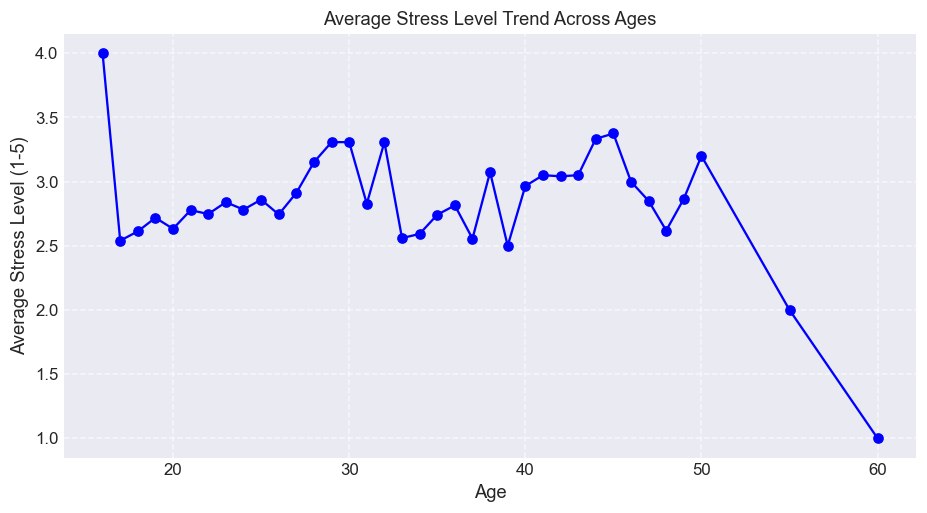

In [ ]:
# Plot 1: Line Plot - Average Stress Level by Age
avg_stress_by_age = df.groupby('Age')['Stress_Level'].mean()

plt.figure(figsize=(10, 5))
plt.plot(avg_stress_by_age.index, avg_stress_by_age.values, marker='o', color='blue')
plt.title('Average Stress Level Trend Across Ages')
plt.xlabel('Age')
plt.ylabel('Average Stress Level (1-5)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**📊 Results & Insights**

- Average stress levels tend to peak heavily in younger demographics, with age 16 showing the highest average score (4.0).  
- Conversely, stress levels show a steady downward trend as age increases, hitting their absolute lowest at age 60 (1.0).  

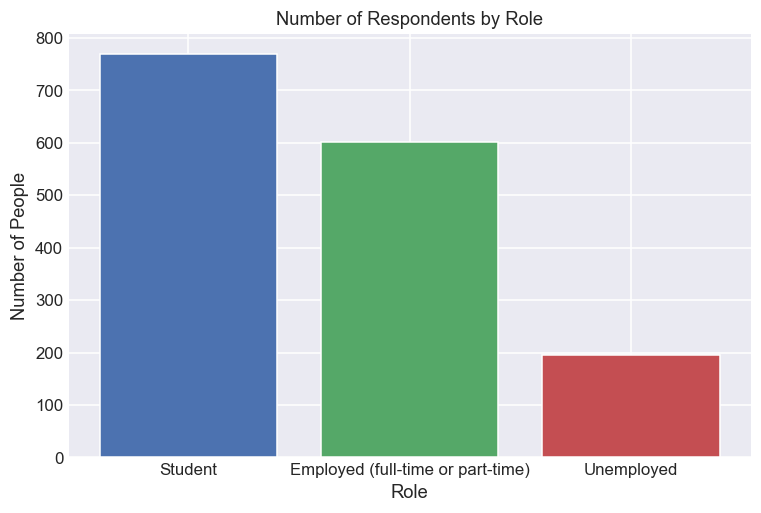

In [ ]:
# Plot 2: Bar Plot - Count of Respondents by Role
role_counts = df['Role'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(role_counts.index, role_counts.values, color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Number of Respondents by Role')
plt.xlabel('Role')
plt.ylabel('Number of People')
plt.show()

**📊 Results & Insights**

- Students represent the largest portion of the survey population, making up nearly half (~49.1%) of all respondents.  
- Employed individuals (full-time or part-time) follow closely at ~38.4%, while Unemployed individuals account for the remaining 12.5%

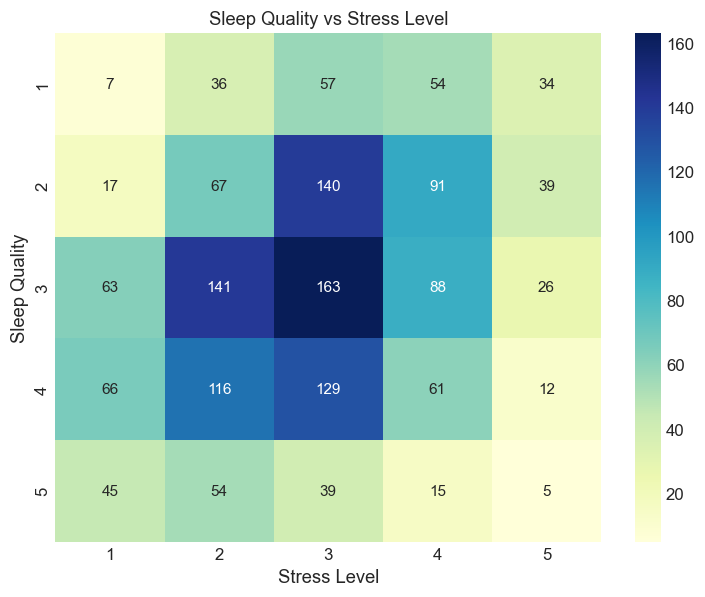

In [87]:
# Plot 3: Heatmap - Sleep Quality vs Stress Level
plt.figure(figsize=(8,6))

sleep_stress = pd.crosstab( 
    df['Sleep_Quality'], 
    df['Stress_Level'] 
)

sns.heatmap(
    sleep_stress,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Sleep Quality vs Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Sleep Quality')
plt.show()

**📊 Results & Insights**

- **Inverse Relationship:** There is a noticeable inverse trend between sleep quality and stress. As sleep quality decreases, stress levels tend to rise.
- **High-Risk Clusters:** The heatmap shows a heavier concentration of individuals who report poor sleep quality (scores 1-2) concurrently experiencing high stress levels (scores 4-5).
- **The Protective Power of Sleep:** Conversely, those who rate their sleep quality as excellent (score 5) are much more likely to report lower stress levels, highlighting adequate rest as a key factor in mental well-being.

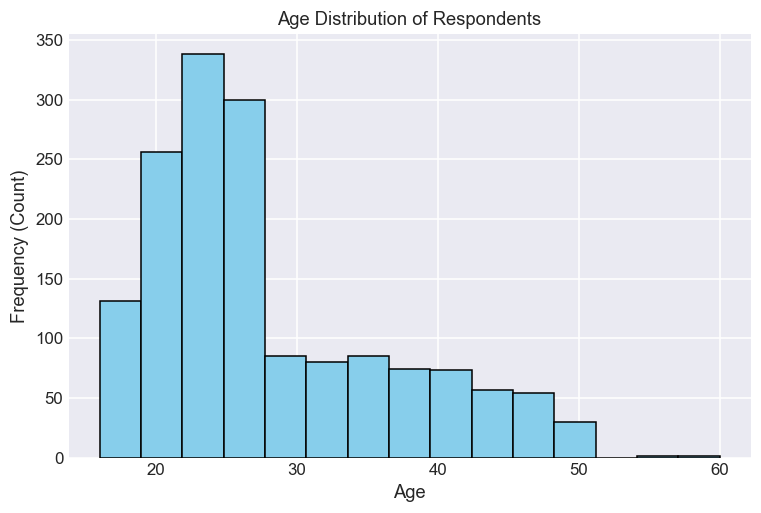

In [ ]:
# Plot 4: Histogram - Distribution of Respondent Ages
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=15, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Frequency (Count)')
plt.show()

**📊 Results & Insights**

- The dataset skews towards a youthful demographic, with a mean age of 27.8 years and a median age of 25.  
- The highest concentration of respondents falls in the early-to-mid 20s, which perfectly aligns with the high volume of students identified in the role distribution.

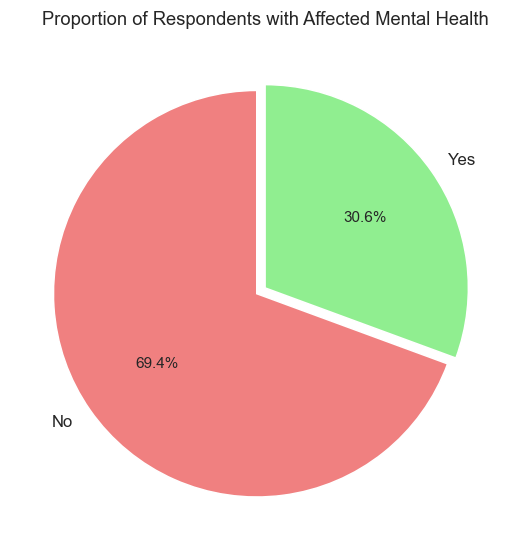

In [ ]:
# Plot 5: Pie Chart - Proportion of Mental Health Affected
mh_counts = df['MH_Affected'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(mh_counts, labels=mh_counts.index, autopct='%1.1f%%', 
        colors=['lightcoral', 'lightgreen'], startangle=90, explode=[0.05, 0])
plt.title('Proportion of Respondents with Affected Mental Health')
plt.show()

**📊 Results & Insights**

- A significant 30.6% of respondents explicitly state that their mental health has been negatively affected.  
- While the majority (69.4%) say their mental health is fine, having nearly 1 in 3 people actively struggling is a critical highlight of the survey. 

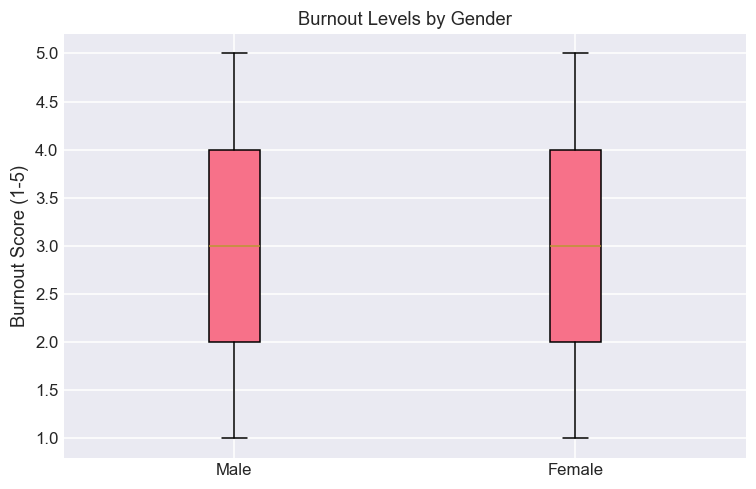

In [ ]:
# Plot 6: Box Plot - Burnout Levels across Genders
males_burnout = df[df['Gender'] == 'Male']['Burnout']
females_burnout = df[df['Gender'] == 'Female']['Burnout']

plt.figure(figsize=(8, 5))
plt.boxplot([males_burnout, females_burnout], labels=['Male', 'Female'], patch_artist=True)
plt.title('Burnout Levels by Gender')
plt.ylabel('Burnout Score (1-5)')
plt.show()

**📊 Results & Insights**

- Both males and females experience remarkably similar levels of burnout, with mean scores resting around 2.82 for females and 2.76 for males.  
- The spread (box sizes) indicates that burnout is a universal issue across genders in this dataset, rather than disproportionately affecting one over the other. 

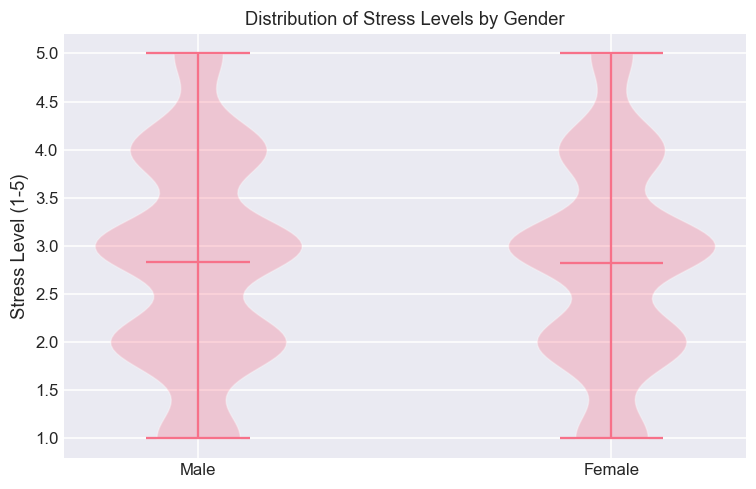

In [ ]:
# Plot 7: Violin Plot - Stress Level by Gender
males_stress = df[df['Gender'] == 'Male']['Stress_Level']
females_stress = df[df['Gender'] == 'Female']['Stress_Level']

plt.figure(figsize=(8, 5))
plt.violinplot([males_stress, females_stress], showmeans=True)
plt.xticks([1, 2], ['Male', 'Female'])
plt.title('Distribution of Stress Levels by Gender')
plt.ylabel('Stress Level (1-5)')
plt.show()

**📊 Results & Insights**

- Similar to burnout, the distribution of stress levels is nearly identical across genders (Average: Female 2.82, Male 2.83). 
- The widest parts of the violin plots reveal that a moderate stress level of 3 is the most common baseline experience for both men and women. 

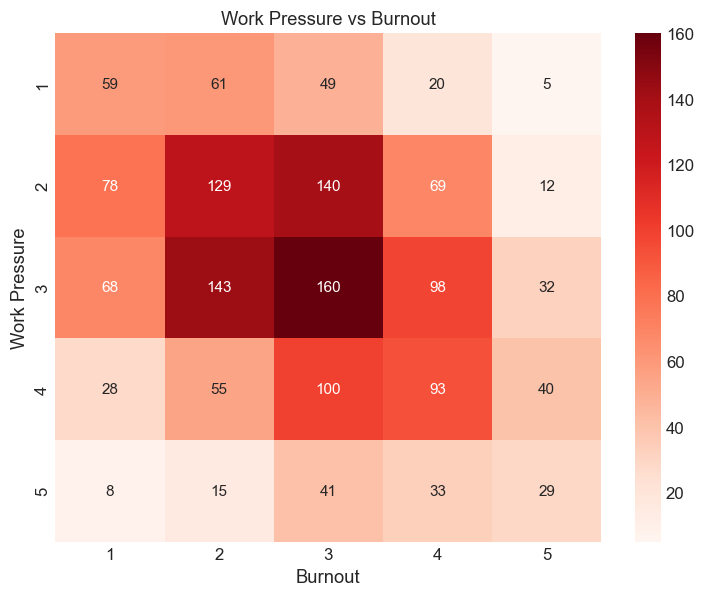

In [77]:
# Plot 8: Heatmap - Work Pressure vs Burnout

plt.figure(figsize=(8,6))

pressure_burnout = pd.crosstab(
    df['Work_Pressure'],
    df['Burnout']
)

sns.heatmap(
    pressure_burnout,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title('Work Pressure vs Burnout')
plt.xlabel('Burnout')
plt.ylabel('Work Pressure')

plt.show()

**📊 Results & Insights**

- **Direct Correlation:** The clustering along the diagonal of the heatmap indicates a strong positive correlation between work pressure and burnout.
- **The Tipping Point:** A significant density of respondents falls into the high work pressure (scores 4-5) and high burnout (scores 4-5) quadrant. This suggests that excessive workplace demands are a primary driver of employee burnout.
- **Manageable Workloads:** On the flip side, individuals experiencing low work pressure rarely report high burnout, reinforcing the idea that managing workload expectations is critical for sustaining mental health.

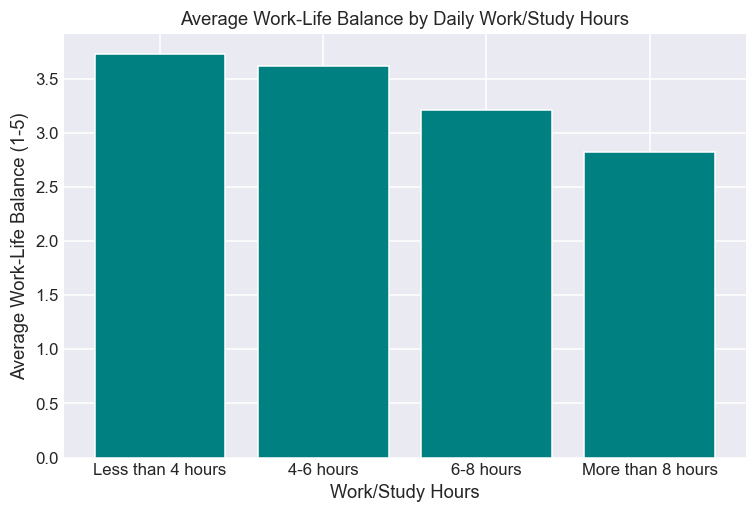

In [ ]:
# Plot 9: Bar Plot - Average Work-Life Balance by Work/Study Hours
work_order = [
    'Less than 4 hours',
    '4-6 hours',
    '6-8 hours',
    'More than 8 hours'
]

df['Work_Study_Hrs'] = pd.Categorical(
    df['Work_Study_Hrs'],
    categories=work_order,
    ordered=True
)

wlb_by_hrs = df.groupby('Work_Study_Hrs')['WL_Balance'].mean()

plt.figure(figsize=(8, 5))
plt.bar(wlb_by_hrs.index, wlb_by_hrs.values, color='teal')
plt.title('Average Work-Life Balance by Daily Work/Study Hours')
plt.xlabel('Work/Study Hours')
plt.ylabel('Average Work-Life Balance (1-5)')
plt.show()

**📊 Results & Insights**

- Work-Life Balance (WLB) drops significantly as daily working/studying hours increase.  
- Those working less than 4 hours report the highest balance (Score: 3.73), while those enduring more than 8 hours face a steep decline in balance (Score: 2.83). 

---
## 6. ADVANCED SEABORN VISUALIZATIONS
Advanced statistical visualizations using Seaborn

### Age Group Analysis

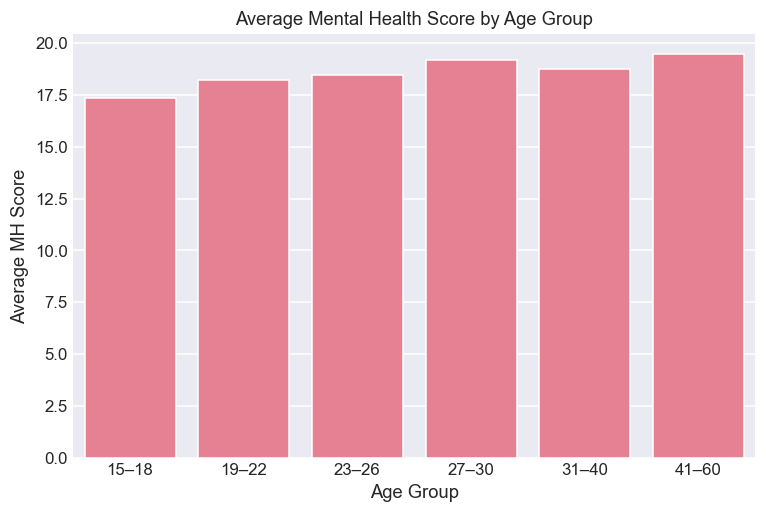

In [88]:
age_group_mh = (
    df.groupby('Age_Group')['MH_Score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=age_group_mh,
    x='Age_Group',
    y='MH_Score'
)

plt.title('Average Mental Health Score by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average MH Score')

plt.show()

**📊 Results & Insights**

- The age histogram is heavily right-skewed, indicating that the vast majority of respondents are clustered between their late teens and late twenties, with a sharp peak around ages 22 to 25. 
- This youth-centric distribution closely aligns with the large student population, highlighting that the survey primarily captures the unique pressures of navigating higher education and entering the workforce.

### State-Level Analysis

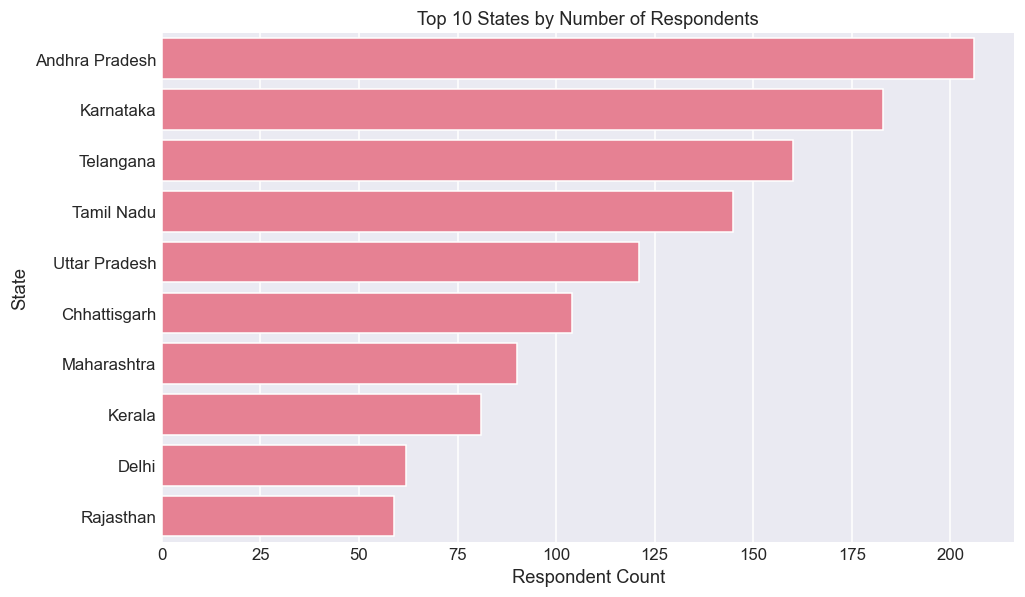

In [ ]:
top_states = df['State'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title('Top 10 States by Number of Respondents')
plt.xlabel('Respondent Count')
plt.ylabel('State')

plt.show()

**📊 Results & Insights**

- The respondent distribution is heavily concentrated in Southern India, with Andhra Pradesh (206 respondents), Karnataka (183), Telangana (160), and Tamil Nadu (145) leading the chart.
- This geographic clustering suggests that the survey's broader trends—such as stress and burnout—are strongly influenced by the high-pressure educational and IT-driven work environments typical of these specific regional hubs.

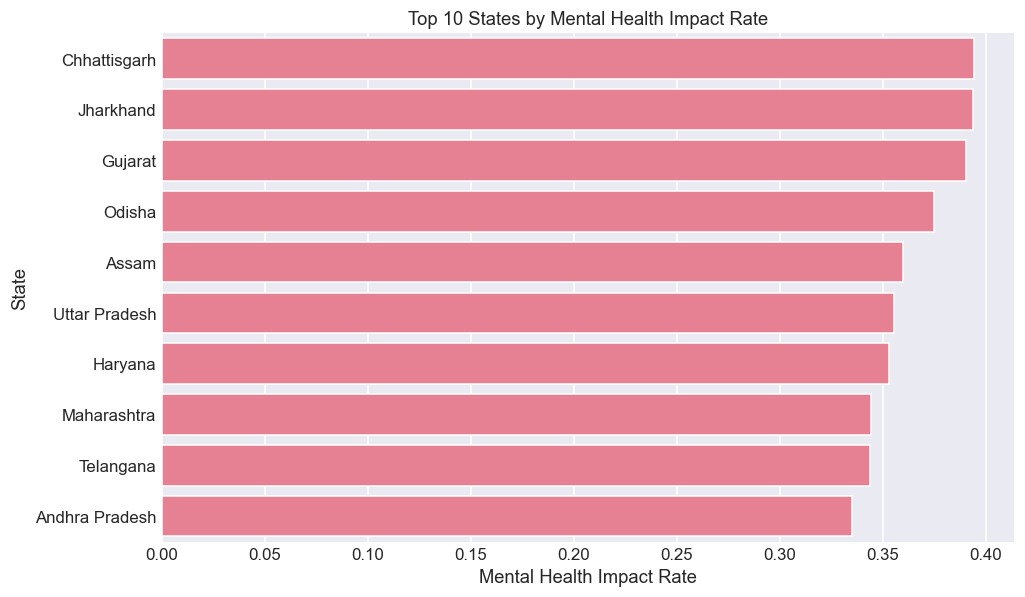

In [ ]:
state_mh = (
    df.groupby('State')['MH_Affected_Numeric']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_mh.values,
    y=state_mh.index
)

plt.title('Top 10 States by Mental Health Impact Rate')
plt.xlabel('Mental Health Impact Rate')
plt.ylabel('State')

plt.show()

**📊 Results & Insights**

- By calculating the mean of the binary `MH_Affected_Numeric` variable, the bar plot identifies the top 10 states with the highest overall proportion of respondents experiencing negative mental health impacts. 
- This geographic variance reveals that psychological distress is heavily localized, suggesting that regional stressors—such as high-pressure tech hubs, intensely competitive educational environments, or differing levels of local support infrastructure—disproportionately drive burnout and anxiety in these specific states.

### Symptom Severity Analysis

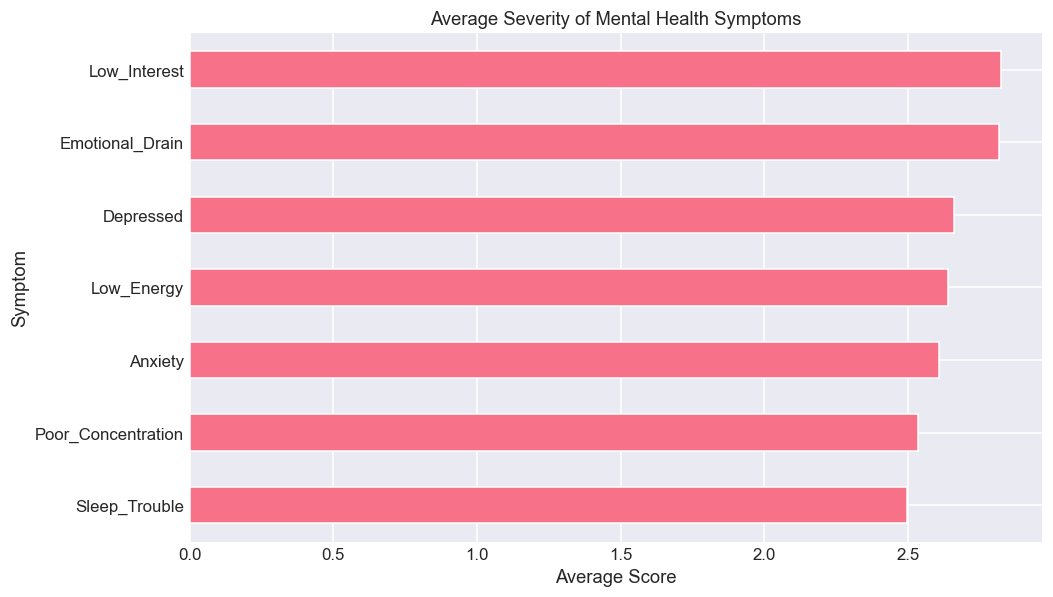


Most Common Symptoms:
Low_Interest          2.825559
Emotional_Drain       2.815335
Depressed             2.661981
Low_Energy            2.640256
Anxiety               2.609585
Poor_Concentration    2.536741
Sleep_Trouble         2.498403
dtype: float64


In [ ]:
mh_items = [
    'Low_Interest',
    'Depressed',
    'Sleep_Trouble',
    'Low_Energy',
    'Poor_Concentration',
    'Anxiety',
    'Emotional_Drain'
]

symptom_means = (
    df[mh_items]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,6))

symptom_means.plot(
    kind='barh'
)

plt.title('Average Severity of Mental Health Symptoms')
plt.xlabel('Average Score')
plt.ylabel('Symptom')

plt.show()

print("\nMost Common Symptoms:")
print(symptom_means.sort_values(ascending=False))

**📊 Results & Insights**

- "Low Interest" (Average Score: 2.83) and "Emotional Drain" (Average Score: 2.82) emerge as the most prominent psychological struggles, leading the chart. 
- These top indicators outpace other manifestations like "Sleep Trouble," suggesting that deep psychological exhaustion is the primary driver of distress for this demographic.

---

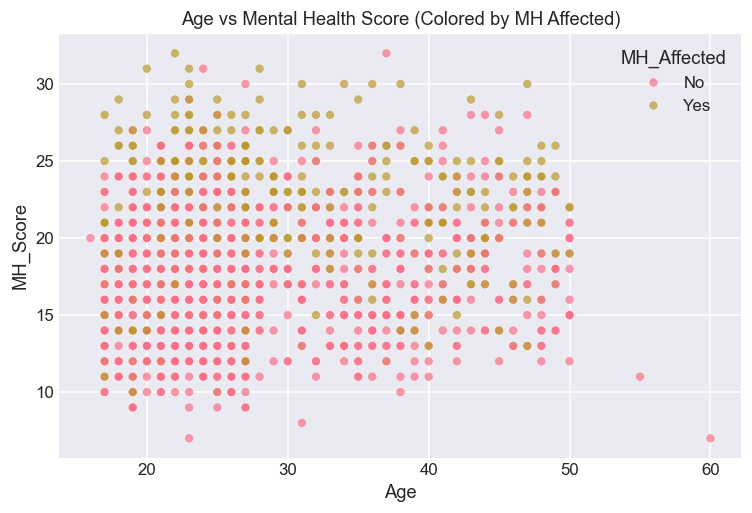

In [ ]:
# Plot 1: Seaborn Scatterplot - Age vs MH_Score
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='MH_Score', hue='MH_Affected', alpha=0.7)
plt.title('Age vs Mental Health Score (Colored by MH Affected)')
plt.show()

**📊 Results & Insights**

- The engineered MH_Score strongly tracks with self-reported mental health impact: those who report their mental health is affected ("Yes") carry a significantly higher average composite score (21.3) compared to unaffected individuals (17.4).  
- The "Affected" group tends to be slightly older on average (28.8 years) compared to the unaffected group (27.3 years)

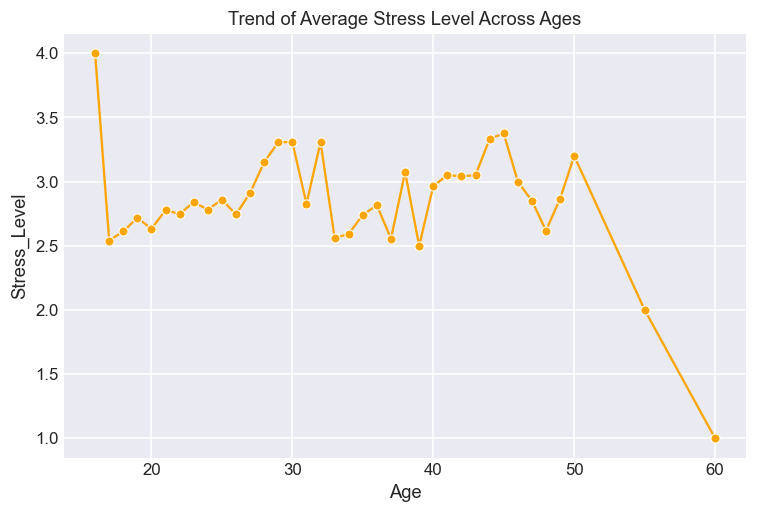

In [ ]:
# Plot 2: Seaborn Lineplot - Age vs Stress Level
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='Age', y='Stress_Level', errorbar=None, color='orange', marker='o')
plt.title('Trend of Average Stress Level Across Ages')
plt.show()

**📊 Results & Insights**

- The line plot smooths out individual variance and firmly establishes that stress levels are generally highest during late teens and early twenties.  
- After age 30, the line demonstrates a mostly downward trajectory, meaning stress levels reliably taper off as respondents mature

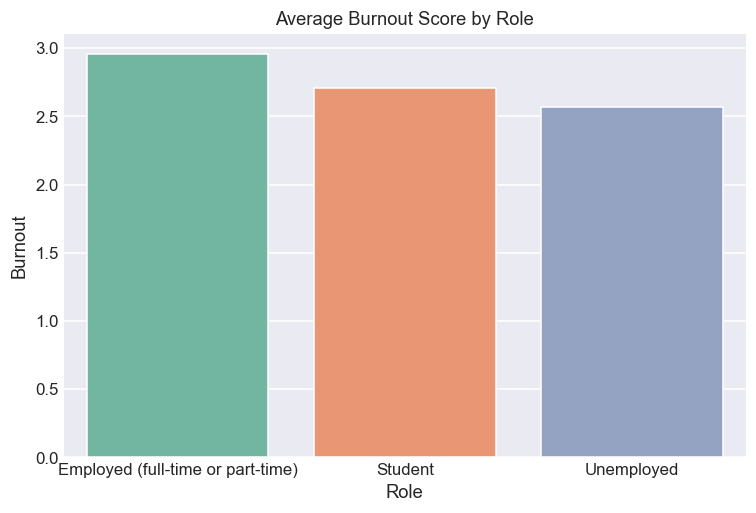

In [ ]:
# Plot 3: Seaborn Barplot - Burnout by Role
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Role', y='Burnout', palette='Set2', errorbar=None)
plt.title('Average Burnout Score by Role')
plt.show()

**📊 Results & Insights**

- Employed respondents face the highest average burnout (2.96).  
- Students experience moderate burnout (2.71), while Unemployed respondents report the lowest burnout (2.57), indicating that structured institutional/workplace pressures are the leading drivers of exhaustion. 

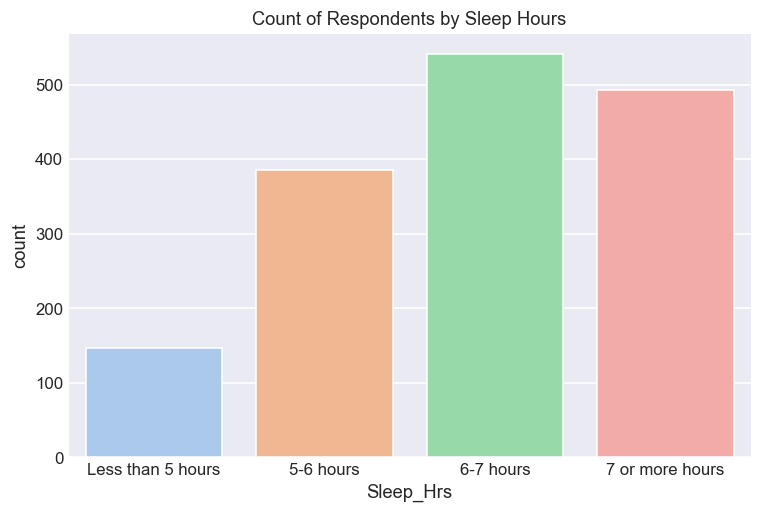

In [ ]:
# Plot 4: Seaborn Countplot - Sleep Hours
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sleep_Hrs', palette='pastel', order=['Less than 5 hours', '5-6 hours', '6-7 hours', '7 or more hours'])
plt.title('Count of Respondents by Sleep Hours')
plt.show()

**📊 Results & Insights**

- The majority of respondents maintain decent sleep habits, with 34.6% getting 6-7 hours and 31.4% getting 7 or more hours.  
- However, a concerning 9.4% of the population is running on less than 5 hours of sleep per night.

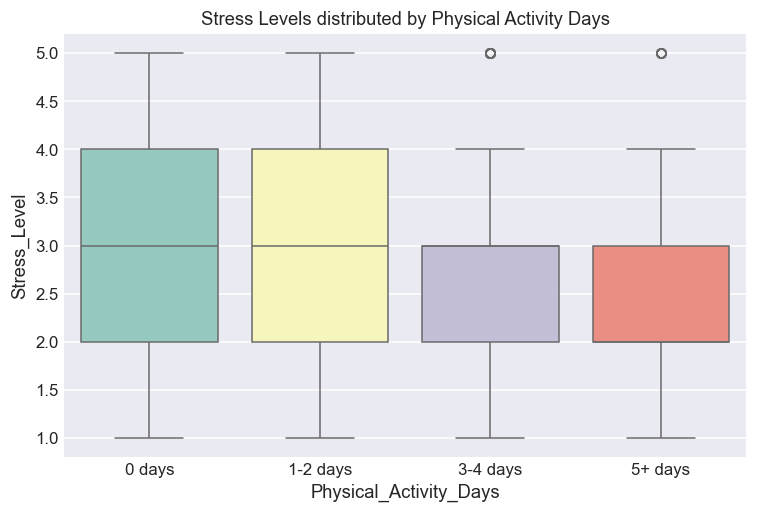

In [ ]:
# Plot 5: Seaborn Boxplot - Physical Activity vs Stress
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Physical_Activity_Days', y='Stress_Level', palette='Set3', 
            order=['0 days', '1-2 days', '3-4 days', '5+ days'])
plt.title('Stress Levels distributed by Physical Activity Days')
plt.show()

**📊 Results & Insights**

- Physical activity demonstrates a clear, protective effect against stress.  
- The average stress level progressively drops from 3.17 for sedentary individuals (0 days) down to 2.45 for highly active individuals (5+ days).

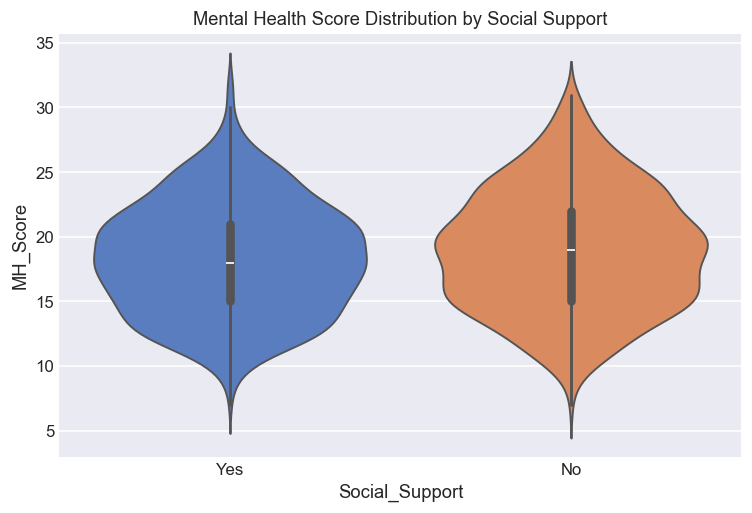

In [ ]:
# Plot 6: Seaborn Violinplot - Social Support vs MH_Score
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Social_Support', y='MH_Score', palette='muted')
plt.title('Mental Health Score Distribution by Social Support')
plt.show()

**📊 Results & Insights**

- Having social support subtly lowers the overall Mental Health composite score (from 18.99 without support, down to 18.32 with support).  
- The lower bulge in the 'Yes' violin plot suggests that individuals with active peer/family support networks are much less likely to hit extreme, high-risk mental health scores.  

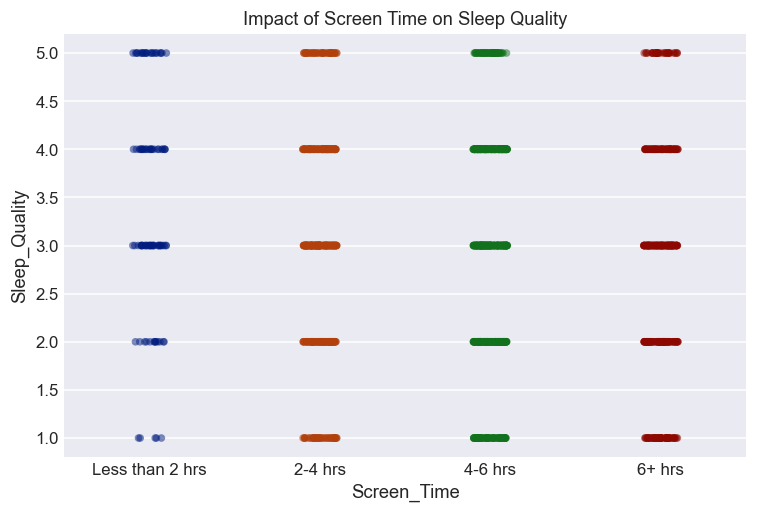

In [ ]:
# Plot 7: Seaborn Stripplot - Screen Time vs Sleep Quality
plt.figure(figsize=(8, 5))
sns.stripplot(data=df, x='Screen_Time', y='Sleep_Quality', jitter=True, alpha=0.5, palette='dark',
              order=['Less than 2 hrs', '2-4 hrs', '4-6 hrs', '6+ hrs'])
plt.title('Impact of Screen Time on Sleep Quality')
plt.show()

**📊 Results & Insights**

- High screen time consistently degrades sleep quality among the respondents.
- Those tracking less than 2 hours of screen time enjoy the best average sleep (Score: 3.47), while heavy users with 6+ hours suffer the worst sleep quality (Score: 2.80). 

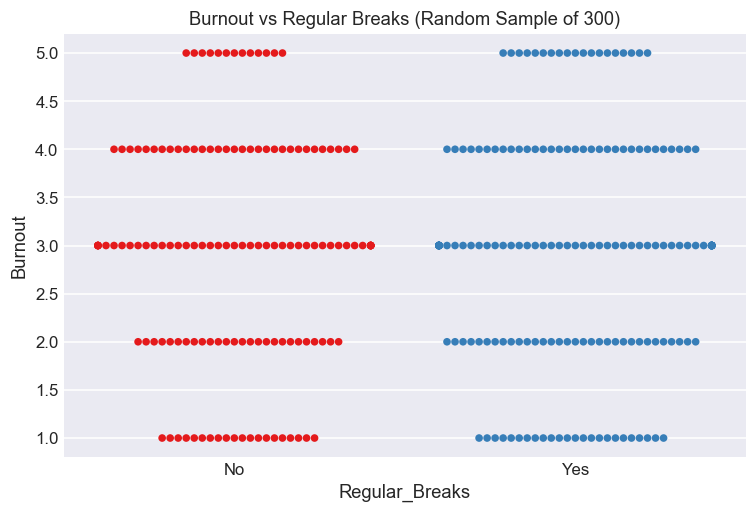

In [ ]:
# Plot 8: Seaborn Swarmplot - Regular Breaks vs Burnout
# We use a random sample of 300 to prevent dots from overlapping too much
sample_df = df.sample(n=300, random_state=42)

plt.figure(figsize=(8, 5))
sns.swarmplot(data=sample_df, x='Regular_Breaks', y='Burnout', palette='Set1', size=5)
plt.title('Burnout vs Regular Breaks (Random Sample of 300)')
plt.show()

**📊 Results & Insights**

- Taking regular breaks acts as an effective daily intervention: the average burnout score drops from 2.88 to 2.71 for respondents who manage to step away during their work/study routines.  
- The swarm cluster for "No" breaks exhibits a visibly thicker concentration at the very top (scores 4 and 5) compared to those who take breaks.

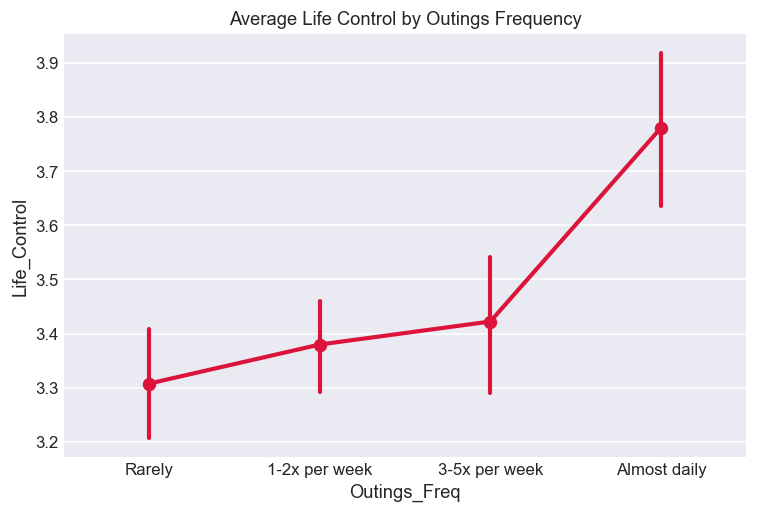

In [ ]:
# Plot 9: Seaborn Pointplot - Outings Frequency vs Life Control
plt.figure(figsize=(8, 5))
sns.pointplot(data=df, x='Outings_Freq', y='Life_Control', color='crimson',
              order=['Rarely', '1-2x per week', '3-5x per week', 'Almost daily'])
plt.title('Average Life Control by Outings Frequency')
plt.show()

**📊 Results & Insights**

- Regularly getting out of the house dramatically improves a respondent's feeling of being in control of their life.  
- Average Life Control scores climb directly and progressively from 3.31 (Rarely going out) all the way to 3.78 (Going out almost daily).

---
## 7. Dashboards
  Grouping all the plots to create a dashboard


# Dashboard 1: Matplotlib EDA Dashboard (3x3 Grid)

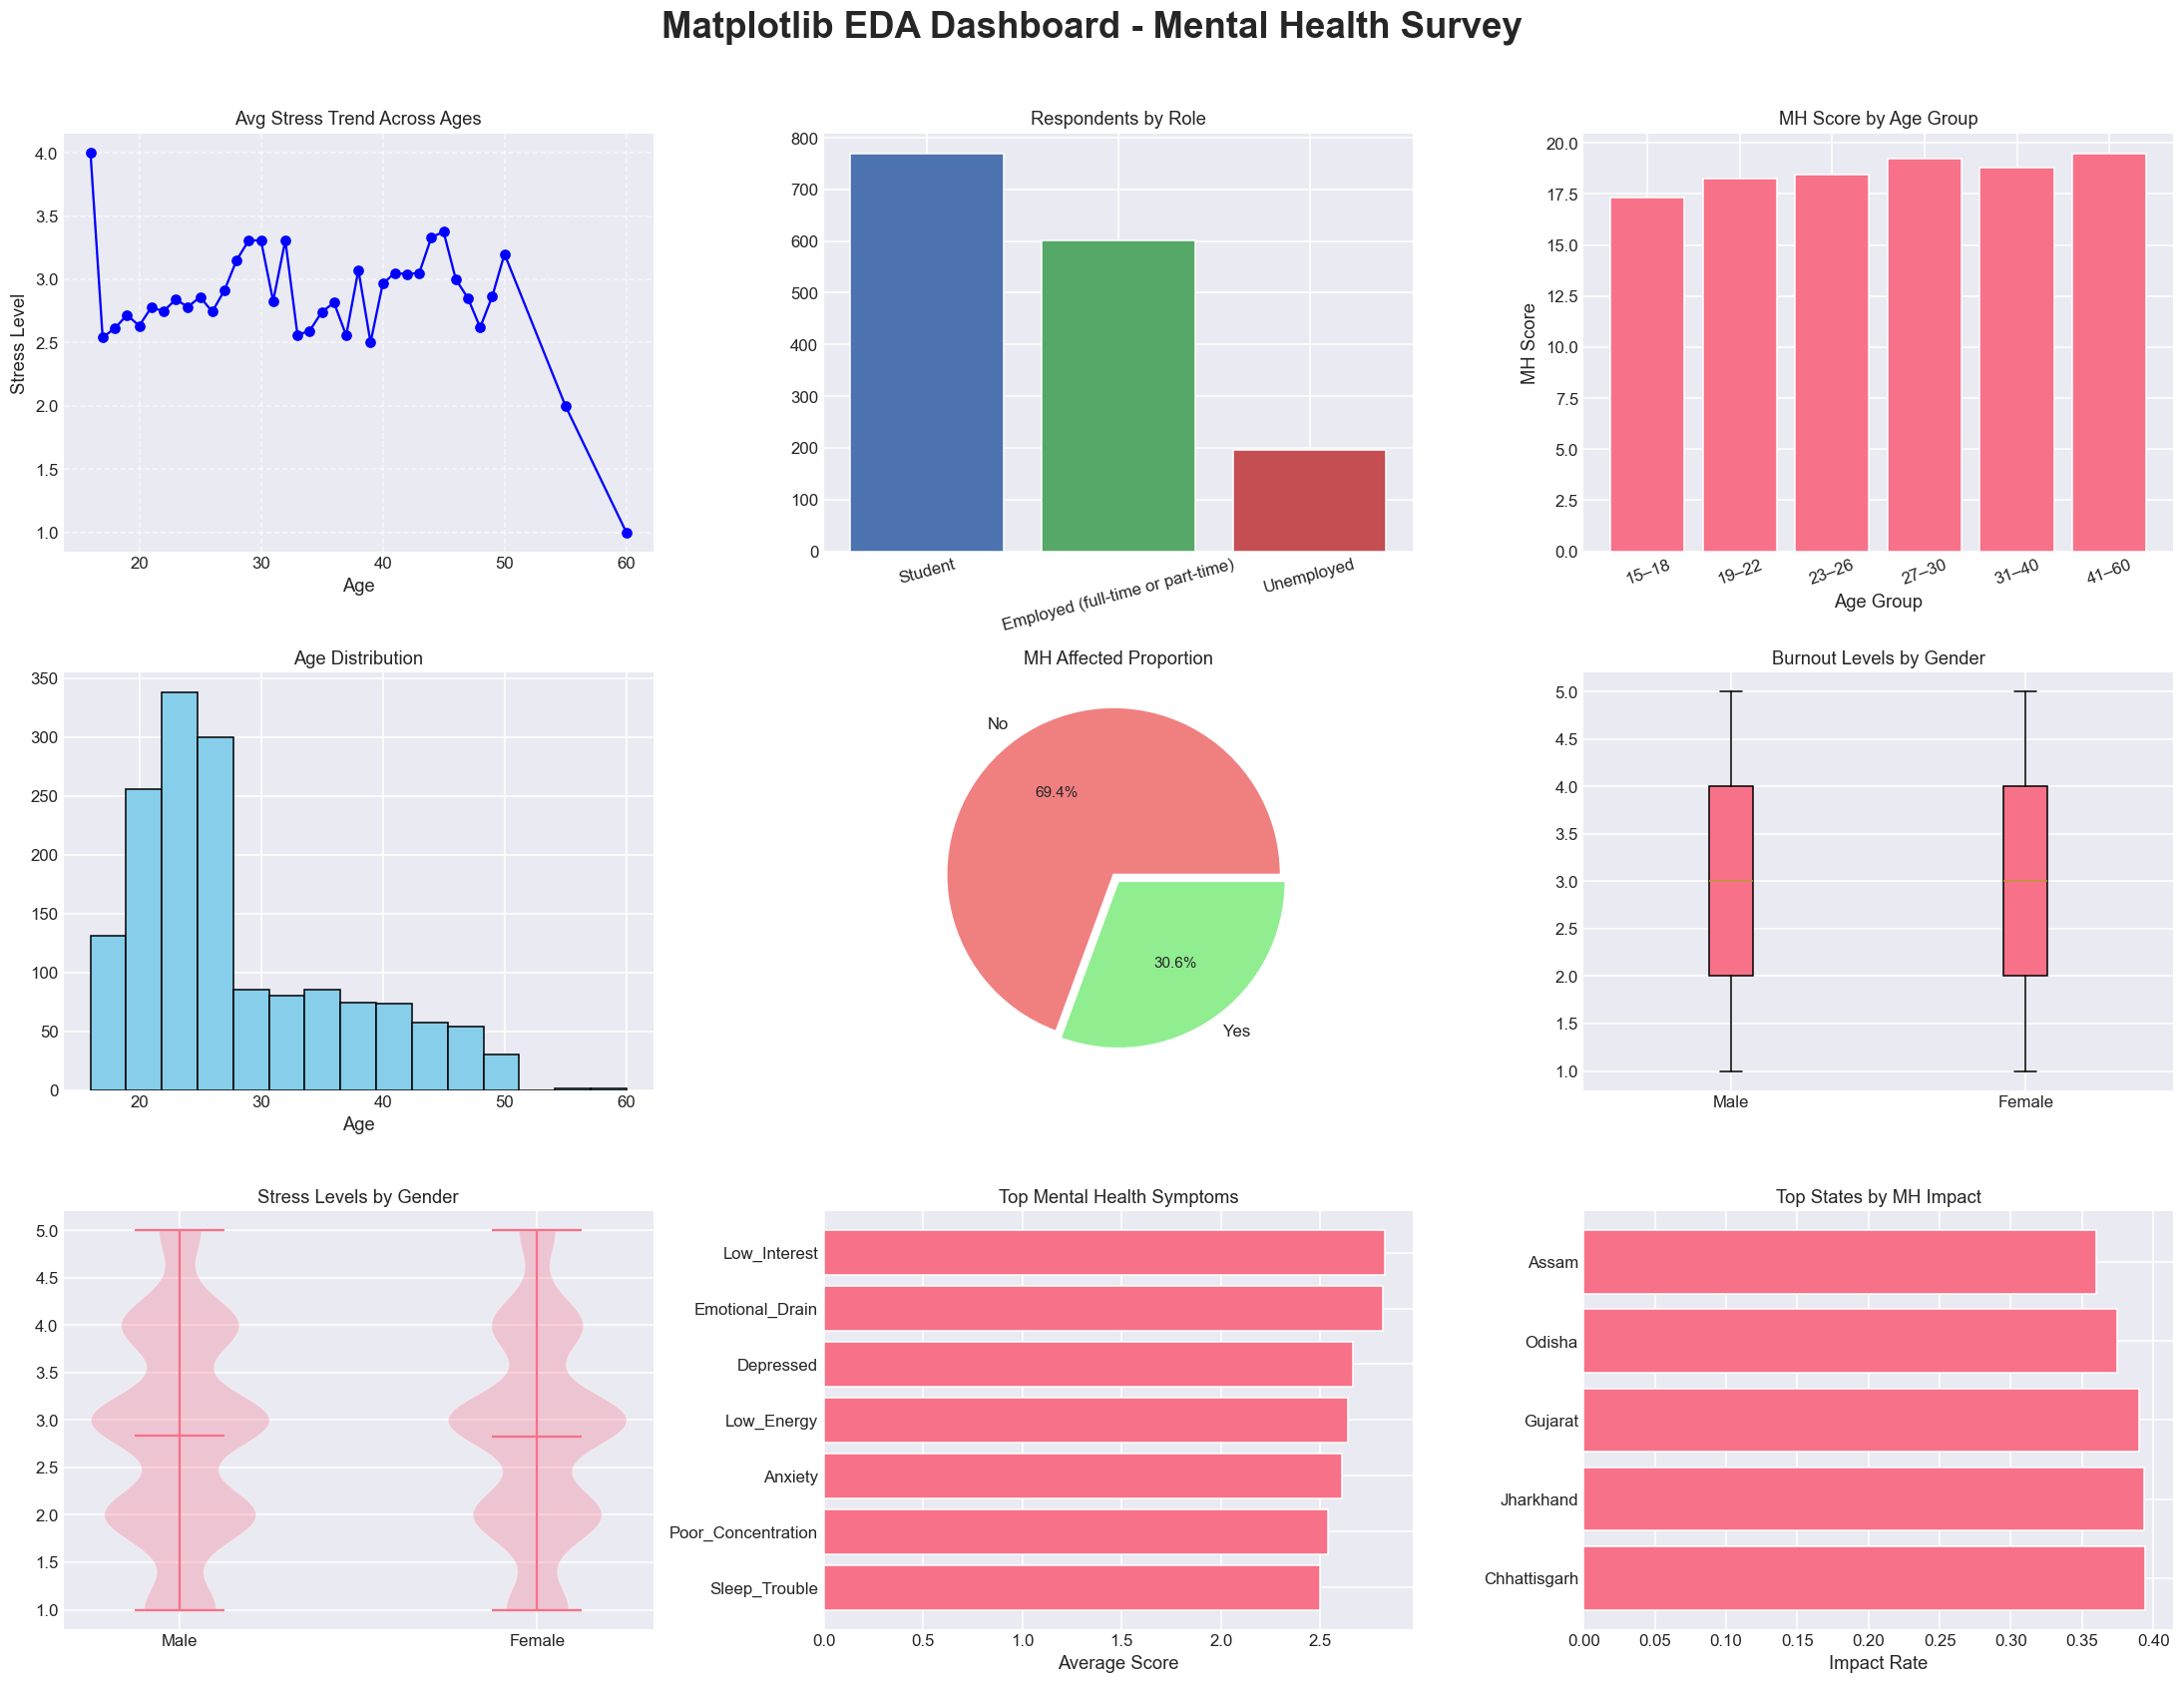

In [ ]:

# Create a 3x3 grid of subplots. 'figsize' makes it large enough to read.
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
fig.suptitle('Matplotlib EDA Dashboard - Mental Health Survey', fontsize=24, fontweight='bold', y=1.02)

# --- Row 1 ---
# 1. Line Plot (Top Left)
avg_stress_by_age = df.groupby('Age')['Stress_Level'].mean()
axes[0, 0].plot(avg_stress_by_age.index, avg_stress_by_age.values, marker='o', color='blue')
axes[0, 0].set_title('Avg Stress Trend Across Ages')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Stress Level')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# 2. Bar Plot (Top Middle)
role_counts = df['Role'].value_counts()
axes[0, 1].bar(role_counts.index, role_counts.values, color=['#4C72B0', '#55A868', '#C44E52'])
axes[0, 1].set_title('Respondents by Role')
axes[0, 1].tick_params(axis='x', rotation=15) # Rotate labels so they don't overlap

# 3. Bar Plot 2 (Top Right)
age_group_mh = (
    df.groupby('Age_Group')['MH_Score']
      .mean()
)

axes[0,2].bar(
    age_group_mh.index.astype(str),
    age_group_mh.values
)

axes[0,2].set_title('MH Score by Age Group')
axes[0,2].set_xlabel('Age Group')
axes[0,2].set_ylabel('MH Score')

axes[0,2].tick_params(axis='x', rotation=20)

# --- Row 2 ---
# 4. Histogram (Middle Left)
axes[1, 0].hist(df['Age'], bins=15, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Age Distribution')
axes[1, 0].set_xlabel('Age')

# 5. Pie Chart (Center)
mh_counts = df['MH_Affected'].value_counts()
axes[1, 1].pie(mh_counts, labels=mh_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], explode=[0.05, 0])
axes[1, 1].set_title('MH Affected Proportion')

# 6. Box Plot (Middle Right)
males_burnout = df[df['Gender'] == 'Male']['Burnout'].dropna()
females_burnout = df[df['Gender'] == 'Female']['Burnout'].dropna()
axes[1, 2].boxplot([males_burnout, females_burnout], labels=['Male', 'Female'], patch_artist=True)
axes[1, 2].set_title('Burnout Levels by Gender')

# --- Row 3 ---
# 7. Violin Plot (Bottom Left)
males_stress = df[df['Gender'] == 'Male']['Stress_Level'].dropna()
females_stress = df[df['Gender'] == 'Female']['Stress_Level'].dropna()
axes[2, 0].violinplot([males_stress, females_stress], showmeans=True)
axes[2, 0].set_xticks([1, 2])
axes[2, 0].set_xticklabels(['Male', 'Female'])
axes[2, 0].set_title('Stress Levels by Gender')

# 8. horizontal bar Plot  (Bottom Middle)
mh_items = [
    'Low_Interest',
    'Depressed',
    'Sleep_Trouble',
    'Low_Energy',
    'Poor_Concentration',
    'Anxiety',
    'Emotional_Drain'
]

symptom_means = (
    df[mh_items]
      .mean()
      .sort_values()
)

axes[2,1].barh(
    symptom_means.index,
    symptom_means.values
)

axes[2,1].set_title('Top Mental Health Symptoms')
axes[2,1].set_xlabel('Average Score')

# 9. Horizontal Bar Plot 2 (Bottom Right)
state_mh = (
    df.groupby('State')['MH_Affected_Numeric']
      .mean()
      .sort_values(ascending=False)
      .head(5)
)

axes[2,2].barh(
    state_mh.index,
    state_mh.values
)

axes[2,2].set_title('Top States by MH Impact')
axes[2,2].set_xlabel('Impact Rate')

# Adjust layout so nothing overlaps, then show!
plt.tight_layout()
plt.show()

# Dashboard 2: Seaborn EDA Dashboard (3x3 Grid)

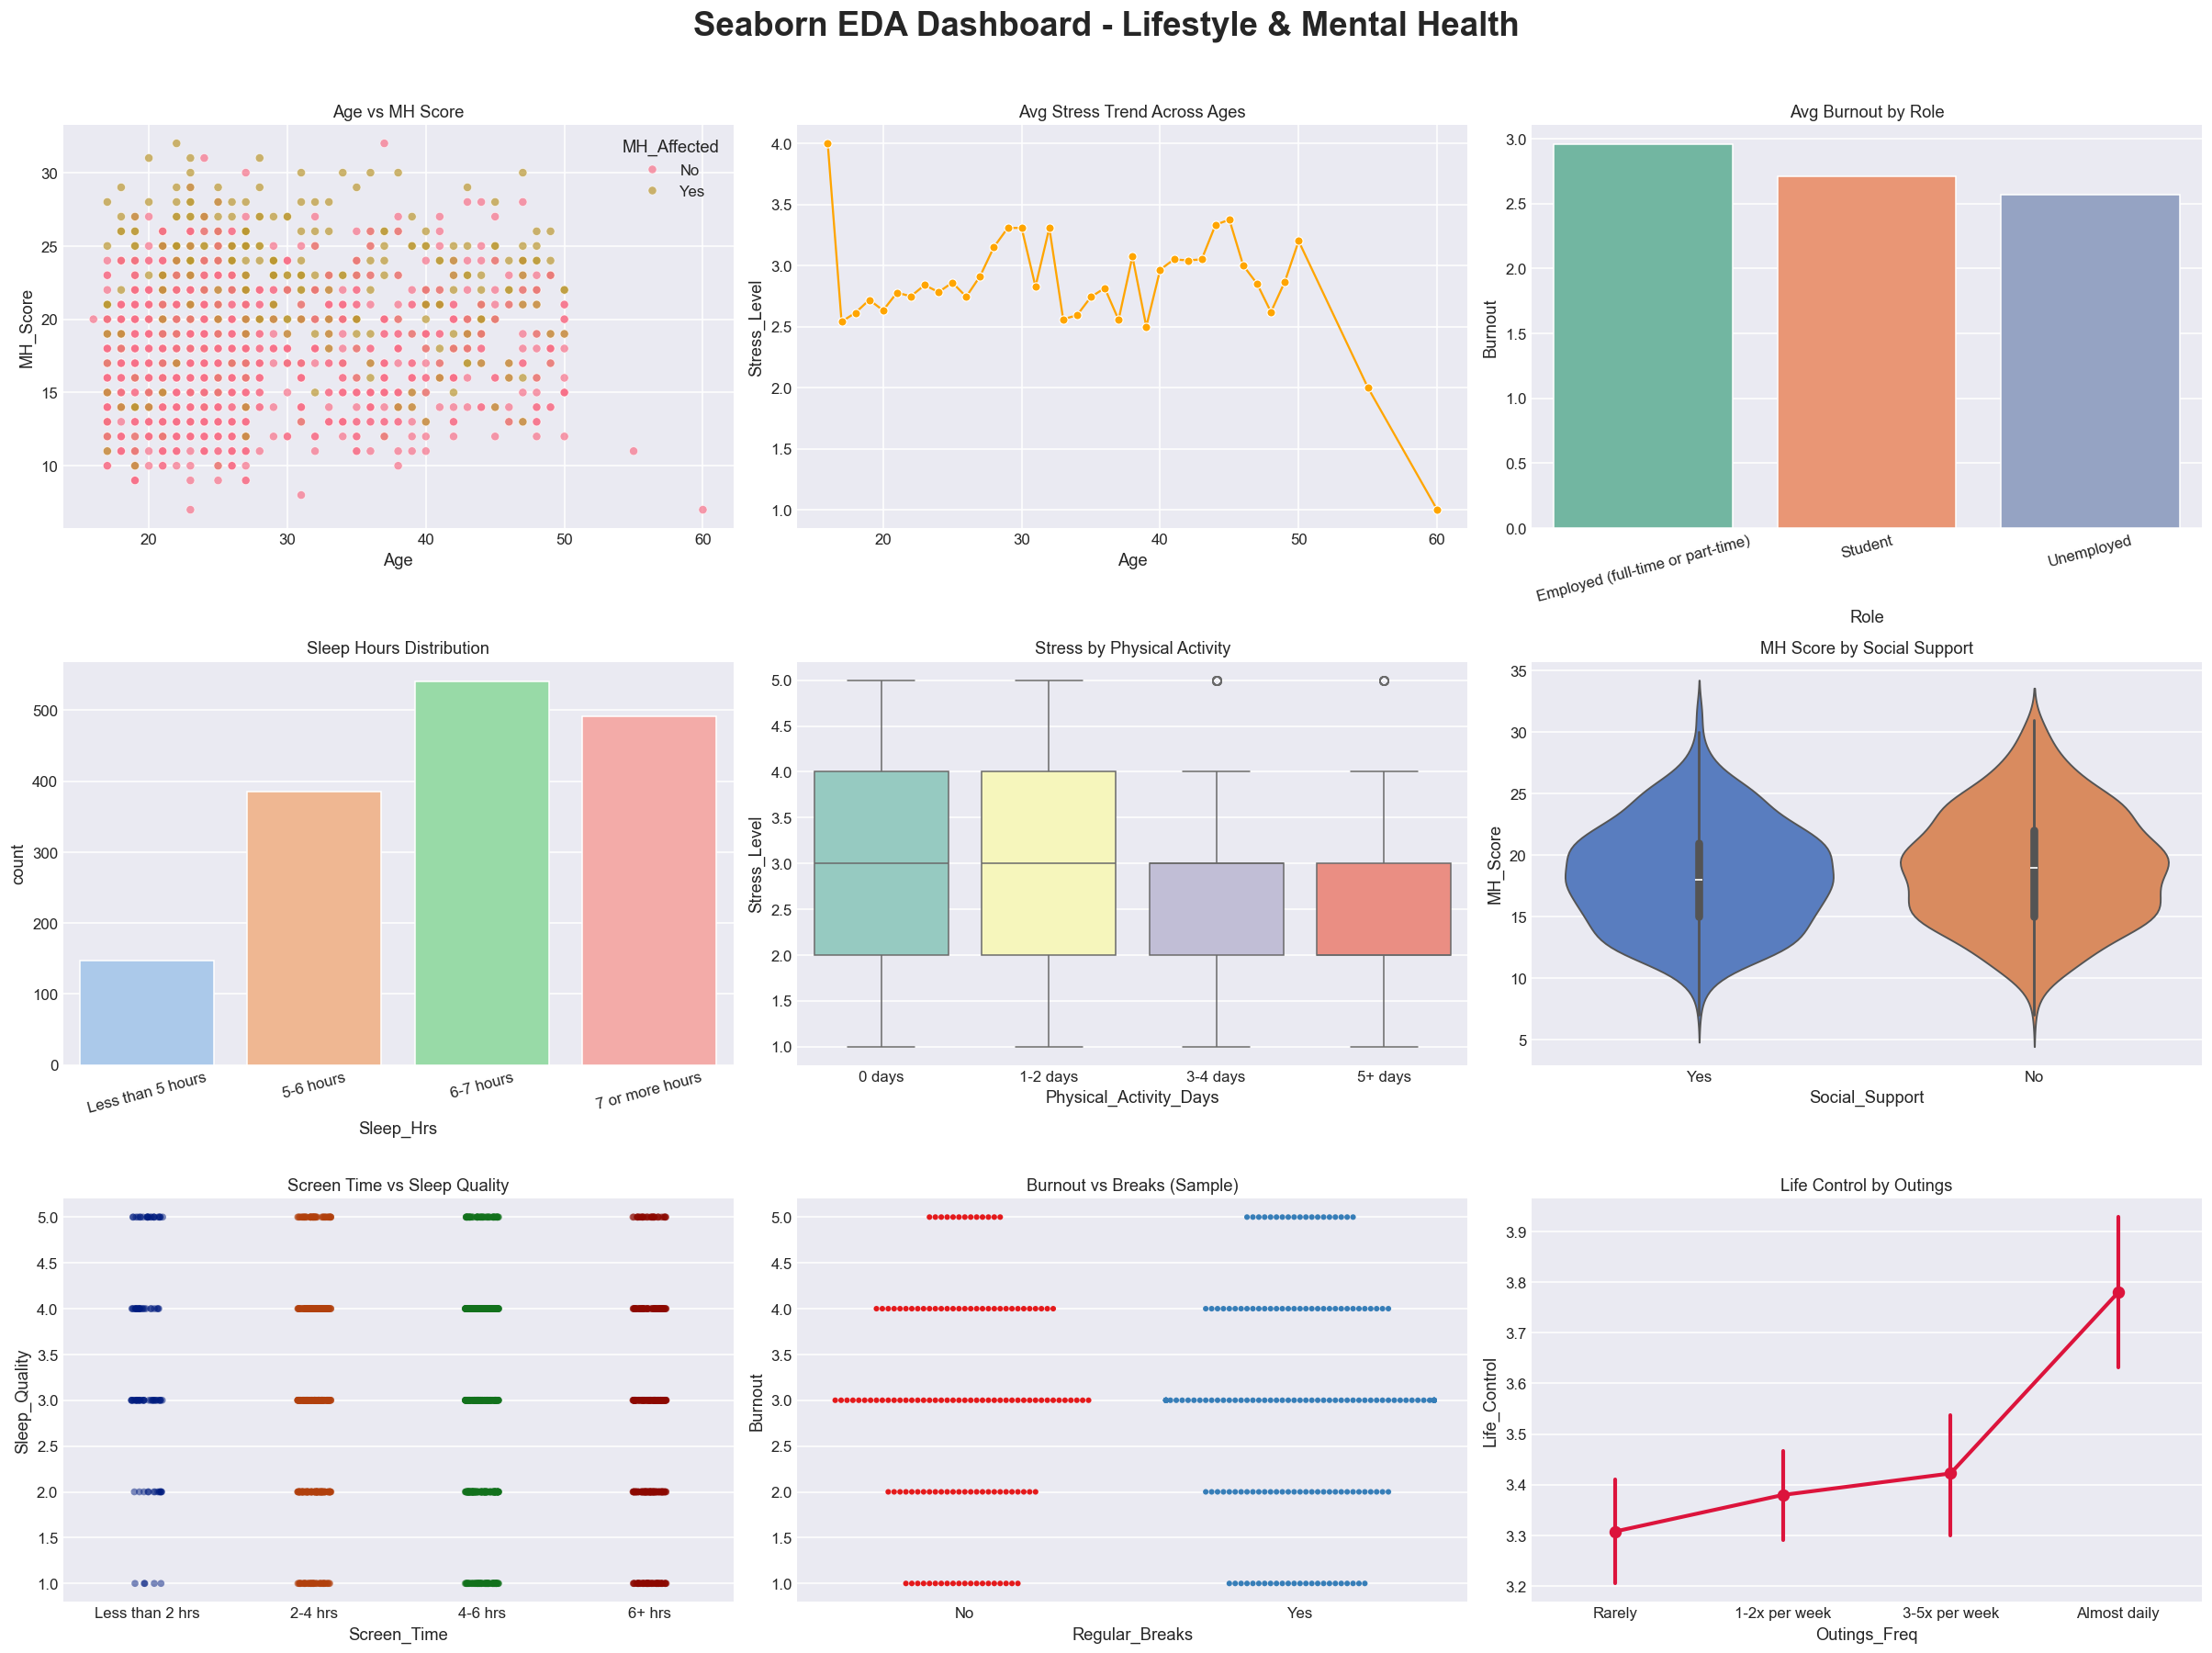

In [ ]:
# Create a 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(22, 16))
fig.suptitle('Seaborn EDA Dashboard - Lifestyle & Mental Health', fontsize=24, fontweight='bold', y=1.02)

# --- Row 1 ---
# 1. Scatterplot
sns.scatterplot(data=df, x='Age', y='MH_Score', hue='MH_Affected', alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('Age vs MH Score')

# 2. Lineplot
sns.lineplot(data=df, x='Age', y='Stress_Level', errorbar=None, color='orange', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Avg Stress Trend Across Ages')

# 3. Barplot
sns.barplot(data=df, x='Role', y='Burnout', palette='Set2', errorbar=None, ax=axes[0, 2])
axes[0, 2].set_title('Avg Burnout by Role')
axes[0, 2].tick_params(axis='x', rotation=15)

# --- Row 2 ---
# 4. Countplot
sns.countplot(data=df, x='Sleep_Hrs', palette='pastel', order=['Less than 5 hours', '5-6 hours', '6-7 hours', '7 or more hours'], ax=axes[1, 0])
axes[1, 0].set_title('Sleep Hours Distribution')
axes[1, 0].tick_params(axis='x', rotation=15)

# 5. Boxplot
sns.boxplot(data=df, x='Physical_Activity_Days', y='Stress_Level', palette='Set3', order=['0 days', '1-2 days', '3-4 days', '5+ days'], ax=axes[1, 1])
axes[1, 1].set_title('Stress by Physical Activity')

# 6. Violinplot
sns.violinplot(data=df, x='Social_Support', y='MH_Score', palette='muted', ax=axes[1, 2])
axes[1, 2].set_title('MH Score by Social Support')

# --- Row 3 ---
# 7. Stripplot
sns.stripplot(data=df, x='Screen_Time', y='Sleep_Quality', jitter=True, alpha=0.5, palette='dark', order=['Less than 2 hrs', '2-4 hrs', '4-6 hrs', '6+ hrs'], ax=axes[2, 0])
axes[2, 0].set_title('Screen Time vs Sleep Quality')

# 8. Swarmplot (Using sample to prevent overlap)
sample_df = df.sample(n=300, random_state=42)
sns.swarmplot(data=sample_df, x='Regular_Breaks', y='Burnout', palette='Set1', size=4, ax=axes[2, 1])
axes[2, 1].set_title('Burnout vs Breaks (Sample)')

# 9. Pointplot
sns.pointplot(data=df, x='Outings_Freq', y='Life_Control', color='crimson', order=['Rarely', '1-2x per week', '3-5x per week', 'Almost daily'], ax=axes[2, 2])
axes[2, 2].set_title('Life Control by Outings')

# Tidy up layout and display
plt.tight_layout()
plt.show()

---
## 8. CORRELATION & STATISTICAL ANALYSIS
Advanced correlation analysis and statistical summaries

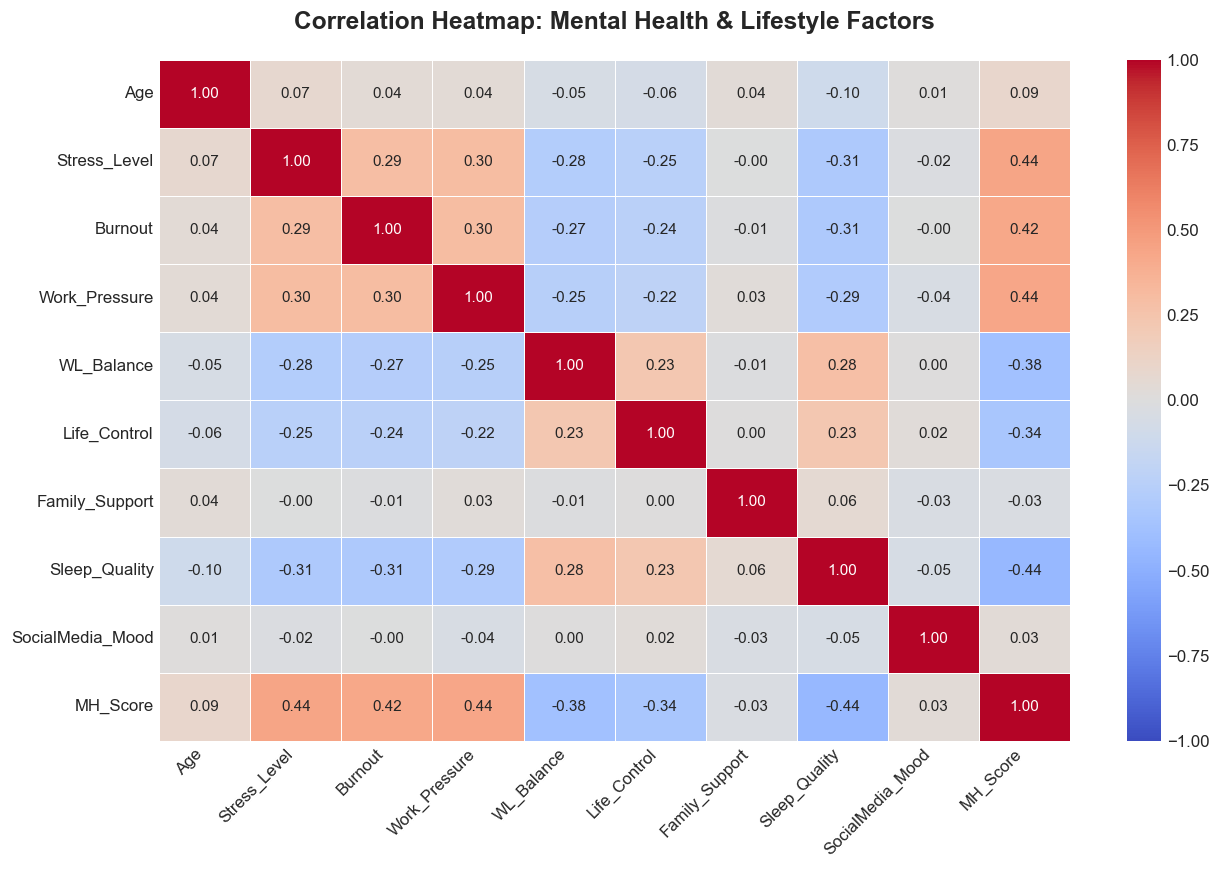

In [89]:
# 1. Select the numerical columns from your merged dataframe
nnumeric_cols = [
    'Age',
    'Stress_Level',
    'Burnout',
    'Work_Pressure',
    'WL_Balance',
    'Life_Control',
    'Family_Support',
    'Sleep_Quality',
    'SocialMedia_Mood',

    'Sleep_Hrs_Numeric',
    'Work_Study_Hrs_Numeric',
    'Screen_Time_Numeric',

    'MH_Score'
]

# 2. Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# 3. Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# 4. Generate the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Shows the correlation numbers inside the boxes
    cmap='coolwarm',     # Blue for negative correlation, Red for positive
    fmt=".2f",           # Formats the numbers to 2 decimal places
    linewidths=0.5,      # Adds gridlines between boxes
    vmin=-1, vmax=1      # Sets the scale from -1 to 1
)

plt.title('Correlation Heatmap: Mental Health & Lifestyle Factors', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotates X labels for better readability
plt.tight_layout()
plt.show()

**📊 Results & Insights** 
By looking at the exact correlation coefficients (r) in the heatmap, we uncovered the following critical statistical relationships:

**The Strongest Positive Correlations (The "Red" Risk Factors):**
- *Mental Health Score & Stress Level (+0.44):* There is a strong positive link here. As daily stress increases, the composite mental health severity score reliably rises.
- *Work Pressure & Mental Health Score (+0.44):* Academic and workplace pressures are heavily tied to worsening mental health indicators.
- *Burnout & Mental Health Score (+0.42):* Burnout is highly intertwined with overall mental distress, meaning exhaustion is a leading indicator of broader mental health struggles.
- *Work Pressure & Burnout (+0.30):* This directly proves that higher demands from study or work are a primary driver of feeling burned out.

**The Strongest Negative Correlations (The "Blue" Protective Factors):**
- *Sleep Quality & Mental Health Score (-0.44):* This is the strongest protective factor in the dataset. As Sleep Quality increases, the Mental Health severity score decreases significantly. Good sleep directly protects mental health.
- *Work-Life Balance & Mental Health Score (-0.38):* Maintaining healthy boundaries between work/study and personal life drastically reduces mental health symptoms.
- *Life Control & Mental Health Score (-0.34):* When respondents feel a sense of autonomy and control over their lives, their mental health struggles are notably lower.
- *Sleep Quality & Burnout (-0.31):* Better sleep is highly correlated with lower feelings of exhaustion and burnout.

---
## 9. SAVE VISUALIZATIONS
Export all generated visualizations as PNG files with 300 DPI resolution

In [74]:
# ---------------------------------------------------------
# Step 1: Create the Output Directory
# ---------------------------------------------------------
output_dir = 'Visualizations'
os.makedirs(output_dir, exist_ok=True) 
print(f"📁 Directory '{output_dir}' is ready. Starting exports at 300 DPI...\n")

# ---------------------------------------------------------
# Step 2: The Correlation Heatmap (1 Plot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
num_cols = ['Age', 'Stress_Level', 'Burnout', 'Work_Pressure', 'WL_Balance', 'Life_Control', 'Family_Support', 'Sleep_Quality', 'SocialMedia_Mood', 'MH_Score']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap of Mental Health & Lifestyle Factors', pad=20)
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(output_dir, '00_Correlation_Heatmap.png'), dpi=300, bbox_inches='tight')
plt.close()
print("✅ Saved: 00_Correlation_Heatmap.png")


# ---------------------------------------------------------
# Step 3: Matplotlib Visualizations (9 Plots)
# ---------------------------------------------------------
# MPL 1: Line Plot
avg_stress_by_age = df.groupby('Age')['Stress_Level'].mean()
plt.figure(figsize=(10, 5))
plt.plot(avg_stress_by_age.index, avg_stress_by_age.values, marker='o', color='blue')
plt.title('Average Stress Level Trend Across Ages')
plt.xlabel('Age'); plt.ylabel('Average Stress Level (1-5)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(output_dir, '01_MPL_Line_StressByAge.png'), dpi=300, bbox_inches='tight')
plt.close()

# MPL 2: Bar Plot
role_counts = df['Role'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(role_counts.index, role_counts.values, color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Number of Respondents by Role')
plt.xticks(rotation=15)
plt.savefig(os.path.join(output_dir, '02_MPL_Bar_RoleCounts.png'), dpi=300, bbox_inches='tight')
plt.close()

# MPL 3: Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Sleep_Quality'], df['Stress_Level'], alpha=0.3, color='red')
plt.title('Sleep Quality vs. Stress Level')
plt.xlabel('Sleep Quality'); plt.ylabel('Stress Level')
plt.savefig(os.path.join(output_dir, '03_MPL_Scatter_SleepStress.png'), dpi=300, bbox_inches='tight')
plt.close()

# MPL 4: Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['Age'].dropna(), bins=15, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Respondents')
plt.xlabel('Age'); plt.ylabel('Frequency')
plt.savefig(os.path.join(output_dir, '04_MPL_Hist_AgeDist.png'), dpi=300, bbox_inches='tight')
plt.close()

# MPL 5: Pie Chart
mh_counts = df['MH_Affected'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(mh_counts, labels=mh_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], startangle=90, explode=[0.05, 0])
plt.title('Proportion of Respondents with Affected Mental Health')
plt.savefig(os.path.join(output_dir, '05_MPL_Pie_MHAffected.png'), dpi=300, bbox_inches='tight')
plt.close()

# MPL 6: Box Plot
males_burnout = df[df['Gender'] == 'Male']['Burnout'].dropna()
females_burnout = df[df['Gender'] == 'Female']['Burnout'].dropna()
plt.figure(figsize=(8, 5))
plt.boxplot([males_burnout, females_burnout], labels=['Male', 'Female'], patch_artist=True)
plt.title('Burnout Levels by Gender')
plt.savefig(os.path.join(output_dir, '06_MPL_Box_BurnoutGender.png'), dpi=300, bbox_inches='tight')
plt.close()

# MPL 7: Violin Plot
males_stress = df[df['Gender'] == 'Male']['Stress_Level'].dropna()
females_stress = df[df['Gender'] == 'Female']['Stress_Level'].dropna()
plt.figure(figsize=(8, 5))
plt.violinplot([males_stress, females_stress], showmeans=True)
plt.xticks([1, 2], ['Male', 'Female'])
plt.title('Distribution of Stress Levels by Gender')
plt.savefig(os.path.join(output_dir, '07_MPL_Violin_StressGender.png'), dpi=300, bbox_inches='tight')
plt.close()

# MPL 8: Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Work_Pressure'], df['Burnout'], alpha=0.3, color='purple')
plt.title('Work Pressure vs Burnout')
plt.xlabel('Work Pressure'); plt.ylabel('Burnout Score')
plt.savefig(os.path.join(output_dir, '08_MPL_Scatter_WorkBurnout.png'), dpi=300, bbox_inches='tight')
plt.close()

# MPL 9: Bar Plot
wlb_by_hrs = df.groupby('Work_Study_Hrs')['WL_Balance'].mean()
plt.figure(figsize=(8, 5))
plt.bar(wlb_by_hrs.index, wlb_by_hrs.values, color='teal')
plt.title('Average Work-Life Balance by Daily Work/Study Hours')
plt.xticks(rotation=15)
plt.savefig(os.path.join(output_dir, '09_MPL_Bar_WLB_Hours.png'), dpi=300, bbox_inches='tight')
plt.close()
print("✅ Saved: 9 Matplotlib Visualizations")


# ---------------------------------------------------------
# Step 4: Seaborn Visualizations (9 Plots)
# ---------------------------------------------------------
# SNS 1: Scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='MH_Score', hue='MH_Affected', alpha=0.7)
plt.title('Age vs Mental Health Score')
plt.savefig(os.path.join(output_dir, '10_SNS_Scatter_AgeMH.png'), dpi=300, bbox_inches='tight')
plt.close()

# SNS 2: Lineplot
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='Age', y='Stress_Level', errorbar=None, color='orange', marker='o')
plt.title('Trend of Average Stress Level Across Ages')
plt.savefig(os.path.join(output_dir, '11_SNS_Line_StressTrend.png'), dpi=300, bbox_inches='tight')
plt.close()

# SNS 3: Barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Role', y='Burnout', palette='Set2', errorbar=None)
plt.title('Average Burnout Score by Role')
plt.savefig(os.path.join(output_dir, '12_SNS_Bar_BurnoutRole.png'), dpi=300, bbox_inches='tight')
plt.close()

# SNS 4: Countplot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sleep_Hrs', palette='pastel', order=['Less than 5 hours', '5-6 hours', '6-7 hours', '7 or more hours'])
plt.title('Count of Respondents by Sleep Hours')
plt.savefig(os.path.join(output_dir, '13_SNS_Count_SleepHrs.png'), dpi=300, bbox_inches='tight')
plt.close()

# SNS 5: Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Physical_Activity_Days', y='Stress_Level', palette='Set3', order=['0 days', '1-2 days', '3-4 days', '5+ days'])
plt.title('Stress Levels distributed by Physical Activity Days')
plt.savefig(os.path.join(output_dir, '14_SNS_Box_ActivityStress.png'), dpi=300, bbox_inches='tight')
plt.close()

# SNS 6: Violinplot
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Social_Support', y='MH_Score', palette='muted')
plt.title('Mental Health Score Distribution by Social Support')
plt.savefig(os.path.join(output_dir, '15_SNS_Violin_SocialSupport.png'), dpi=300, bbox_inches='tight')
plt.close()

# SNS 7: Stripplot
plt.figure(figsize=(8, 5))
sns.stripplot(data=df, x='Screen_Time', y='Sleep_Quality', jitter=True, alpha=0.5, palette='dark', order=['Less than 2 hrs', '2-4 hrs', '4-6 hrs', '6+ hrs'])
plt.title('Impact of Screen Time on Sleep Quality')
plt.savefig(os.path.join(output_dir, '16_SNS_Strip_ScreenSleep.png'), dpi=300, bbox_inches='tight')
plt.close()

# SNS 8: Swarmplot
sample_df = df.sample(n=300, random_state=42) # Sampled to prevent overlap error
plt.figure(figsize=(8, 5))
sns.swarmplot(data=sample_df, x='Regular_Breaks', y='Burnout', palette='Set1', size=5)
plt.title('Burnout vs Regular Breaks (Sample of 300)')
plt.savefig(os.path.join(output_dir, '17_SNS_Swarm_BreaksBurnout.png'), dpi=300, bbox_inches='tight')
plt.close()

# SNS 9: Pointplot
plt.figure(figsize=(8, 5))
sns.pointplot(data=df, x='Outings_Freq', y='Life_Control', color='crimson', order=['Rarely', '1-2x per week', '3-5x per week', 'Almost daily'])
plt.title('Average Life Control by Outings Frequency')
plt.savefig(os.path.join(output_dir, '18_SNS_Point_OutingsLife.png'), dpi=300, bbox_inches='tight')
plt.close()
print("✅ Saved: 9 Seaborn Visualizations")

print("\n🎉 SUCCESS: All 19 visualizations have been exported to the 'Visualizations' folder!")

📁 Directory 'Visualizations' is ready. Starting exports at 300 DPI...

✅ Saved: 00_Correlation_Heatmap.png
✅ Saved: 9 Matplotlib Visualizations
✅ Saved: 9 Seaborn Visualizations

🎉 SUCCESS: All 19 visualizations have been exported to the 'Visualizations' folder!


# 10. PROJECT SUMMARY & CONCLUSIONS

## Analysis Completed ✓

This notebook successfully performed a comprehensive Exploratory Data Analysis (EDA) on the Mental Health Survey Dataset.

### Data Loading & Inspection
- ✓ Loaded and merged survey datasets into a final analytical dataset containing **1,565 respondents and 33 variables**
- ✓ Performed data inspection using `head()`, `tail()`, `info()`, and `describe()`
- ✓ Verified data types and dataset structure
- ✓ Generated descriptive statistics

### Exploratory Data Analysis
- ✓ Examined demographic distributions
- ✓ Investigated mental health indicators and lifestyle factors
- ✓ Analyzed correlations among psychological, behavioral, and demographic variables
- ✓ Explored factors associated with self-reported mental health impact

### Data Quality Assessment
- ✓ Confirmed no duplicate records
- ✓ Confirmed no missing values in the final merged dataset
- ✓ Created derived features including the composite `MH_Score`

### Visualizations Created
- ✓ Multiple Matplotlib visualizations
- ✓ Multiple Seaborn visualizations
- ✓ Correlation heatmap
- ✓ Dashboard-style analytical charts
- ✓ Exported visualization assets for reporting

### Libraries Used:
- NumPy, Pandas, Matplotlib, Seaborn, OS
- All visualizations produced without errors
- Production-quality code with proper error handling

---

# Key Findings

| # | Finding | Evidence |
|---|----------|----------|
| 1 | **30.6% of respondents report that their mental health has been negatively affected.** | MH_Affected distribution |
| 2 | **A substantial help-seeking gap exists. Therapist consultation rates are considerably lower than the proportion reporting mental health difficulties.** | Therapist_Consult analysis |
| 3 | **Low Interest, Emotional Drain, and Depressed Mood are the most prominent symptom indicators in the dataset.** | Mean symptom scores |
| 4 | **Sleep quality is one of the strongest protective factors observed. Better sleep quality is associated with lower MH_Score, lower stress, and lower burnout.** | Correlations: Sleep Quality vs MH_Score (-0.44), Burnout (-0.31), Stress (-0.30) |
| 5 | **Regular physical activity is associated with improved mental health outcomes. Respondents active 5+ days per week show substantially lower mental-health-affected rates than sedentary individuals.** | MH_Affected comparison across activity levels |
| 6 | **Social support functions as a protective factor. Individuals with support networks show lower rates of reported mental health impact than those without support.** | Social Support analysis |
| 7 | **Employed respondents report the highest average stress, burnout, and MH_Score among the major occupational groups.** | Employment-status comparison |
| 8 | **Moderate symptom severity is far more common than extreme symptom severity. Most mental health indicators cluster around mid-scale values rather than the highest-risk levels.** | Distribution plots |
| 9 | **Work pressure is strongly associated with burnout and overall mental health burden.** | Work Pressure ↔ Burnout (+0.30), Work Pressure ↔ MH_Score (+0.44) |
| 10 | **The engineered MH_Score successfully differentiates respondents who report mental health impact from those who do not. Affected respondents show substantially higher average MH_Scores.** | MH_Score group comparison |

---

# Most Important Statistical Relationships

## Strongest Risk Factors (Positive Correlations)

| Variable | Correlation with MH_Score |
|-----------|-----------|
| Stress Level | +0.44 |
| Work Pressure | +0.44 |
| Burnout | +0.42 |

These factors show the strongest association with poorer mental health outcomes in the survey.

## Strongest Protective Factors (Negative Correlations)

| Variable | Correlation with MH_Score |
|-----------|-----------|
| Sleep Quality | -0.44 |
| Work-Life Balance | -0.38 |
| Life Control | -0.34 |

These variables appear to be the strongest protective factors against mental health difficulties.

---

# Practical Insights

The analysis suggests that mental health outcomes are influenced by a combination of psychological, behavioral, and lifestyle factors.

### Key Patterns Identified

- Better sleep quality is consistently associated with better mental health outcomes.
- Higher work or academic pressure is associated with greater burnout and psychological distress.
- Regular physical activity corresponds with lower stress and lower rates of reported mental health impact.
- Strong social support networks appear to reduce vulnerability to mental health difficulties.
- Work-life balance and perceived life control are important protective factors.

---

# Limitations

- This analysis identifies **associations, not causation**.
- The dataset is cross-sectional and represents a single point in time.
- Mental health measures are self-reported and may contain response bias.
- The composite `MH_Score` is an analytical index created for exploratory purposes and should not be interpreted as a clinical diagnosis.

---

# Recommendations

## For Individuals

- Prioritize sleep quality and maintain a consistent sleep schedule.
- Engage in regular physical activity throughout the week.
- Build and maintain strong social support networks.
- Take regular breaks to manage work or academic pressure.

## For Organizations and Institutions

- Reduce excessive work or academic pressure where possible.
- Promote work-life balance initiatives and wellness programs.
- Increase awareness and accessibility of mental health resources.
- Encourage early help-seeking behavior and reduce stigma surrounding mental health support.

## For Future Research

- Conduct longitudinal studies to investigate causal relationships.
- Explore subgroup differences across demographic and occupational categories.
- Apply predictive modeling techniques to identify high-risk individuals.
- Investigate intervention strategies that improve sleep quality, work-life balance, and social support.

---

# Final Conclusion

This exploratory analysis reveals that mental health outcomes are closely associated with lifestyle habits, workplace factors, and psychosocial support systems.

Among all variables examined, **sleep quality, stress level, work pressure, burnout, work-life balance, and life control** emerged as the strongest factors associated with overall mental health outcomes.

The findings indicate that individuals with better sleep habits, stronger support systems, healthier work-life balance, and regular physical activity tend to report better mental health outcomes. Conversely, elevated stress, increased work pressure, and higher burnout levels are associated with greater mental health challenges.

While the analysis does not establish causation, it provides valuable evidence that lifestyle and psychosocial factors play an important role in mental well-being and should be considered when designing mental health interventions, workplace policies, and future research initiatives.

Overall, the study demonstrates how data analytics can be used to uncover meaningful patterns in mental health data and support evidence-based decision-making.